# Домашнее задание: архитектура систем текстовой классификации

Добро пожаловать на бизнес-кейс по текстовой классификации!

В рамках данного домашнего задания вам предстоит пройти по всем этапам решения кейса, которые обычно затрагиваются при решении реальных продуктовых задач, а также кейсов на секциях по ML System Design.

Часть заданий требует текстового ответа в свободной форме, часть заданий - написания кода, обучения и инференса моделей и тп. В большинстве разделов нет сугубо правильных ответов или единственно верной реализации, однако есть хорошие практики и возможность выбрать из нескольких вариантов оптимальный. Поэтому в рамках задания местами надо будет делать выбор, от которого будет зависеть качество вашего потенциального продакшн-решения, возможности его поддержки и масштабирования.

Детали реализации вы можете выбирать любые, которые вам больше нравятся или кажется более удобными, в том числе по принципу "работает быстрее аналогов без существенной потери в качестве". Однако важное требование - **соблюдать структуру разделов в данном ноутбуке** -- это поможет решить задачу правильно, а также упростить проверку и написание фидбека по решению.

Представьте, что к вам пришел бизнес и попросил сделать супер-крутую систему по категоризации новостей. Как обычно бывает, единственное, что у вас есть - это формулировка задачи от продакт-менеджера; всё остальное он ожидает от вас.

Приятного кодинга!

## 1. Формулировка бизнес-задачи

**Контекст (от лица бизнеса):**  
Мы хотим автоматически распределять публикации нашего новостного портала по трем главным темам — политика, экономика, культура — чтобы:

- Улучшить таргетинг рекламных блоков.  
- Персонализировать ленту для пользователей.  
- Снизить ручные затраты редакторов.

**Чёткое описание задачи:**
> «Для каждой новости (заголовок + текст) автоматически определить, относится ли она к разделам `политика`, `экономика`, `культура`. Возможна множественная классификация (одна новость может быть сразу в нескольких разделах).»


## 2. Бизнес-метрики - 1 балл

Предложите бизнес-метрики, которые может хотеть оптимизировать бизнес в соответствии с формулировкой задачи. Предложите хотя три метрики, и постарайтесь их оцифровать, чтобы результаты были измеримы (насколько процентов что-то должно увеличиться?). Воспринимайте это как "прицелочные" цифры, к которым можно реалистично стремиться (реальные цифры на старте часто непонятно, но измеримые цели помогают четче формировать ожидания и текущее положение относительно них; в дальнейшем эти цифры можно корректировать на реальность).

In [2]:
# ваш ответ тут
# ---- Ваш код здесь ----
print("""
метрики для первой итерации в терминологии бизнеса:
      - доля новостей, которые не были автоматически классифицированы (отправлены на ручную проверку) < 15%
      - жалобы от пользователей (редакторов) на неправильную классификацию < 1%
      - latency (время от публикации новости до ее классификации) < 1 секунды
      - throughput (количество новостей, обрабатываемых в единицу времени) > 5000 новостей в час
      - стоимость обработки одной новости < 0.001 USD
      - CTR (кликабельность) по рекламе в разделах новостей - без ухудшения по сравнению с текущим уровнем
метрики для улучшения модели (пока неясно, как их измерять, но можно ориентироваться на них в процессе разработки):
      - доля неверно классифицированных новостей (попали в неверный раздел) < 10%
      - доля новостей, которые не были полностью классифицированы (не попали в нужный раздел) < 15%
Почему эти метрики важны:
      система уменьшает затраты на редакторов, не ухудшая качество и доходы.
""")
# ---- Конец кода ----


метрики для первой итерации в терминологии бизнеса:
      - доля новостей, которые не были автоматически классифицированы (отправлены на ручную проверку) < 15%
      - жалобы от пользователей (редакторов) на неправильную классификацию < 1%
      - latency (время от публикации новости до ее классификации) < 1 секунды
      - throughput (количество новостей, обрабатываемых в единицу времени) > 5000 новостей в час
      - стоимость обработки одной новости < 0.001 USD
      - CTR (кликабельность) по рекламе в разделах новостей - без ухудшения по сравнению с текущим уровнем
метрики для улучшения модели (пока неясно, как их измерять, но можно ориентироваться на них в процессе разработки):
      - доля неверно классифицированных новостей (попали в неверный раздел) < 10%
      - доля новостей, которые не были полностью классифицированы (не попали в нужный раздел) < 15%
Почему эти метрики важны:
      система уменьшает затраты на редакторов, не ухудшая качество и доходы.



## 3. Сведение к ML-задаче - 2 балла

Сведите бизнес-задачу к задаче машинного обучения, опишите входные данные и метки:

- **Тип задачи**:
- **Объект**:
- **Метки**:


In [3]:
# ваш ответ тут
# ---- Ваш код здесь ----
print("""
- **Тип задачи**:
      текстовая классификация (multi-label), фиксированное количество классов
- **Объект**:
      текст и метаданные (источник, заголовок, далее посмотреть на данные, что ещё можно использовать)
- **Метки**:
      3 метки (разделы новостей) - политика, экономика, культура
      в дальнейшем может быть расширение до 5-10 меток
""")
# ---- Конец кода ----


- **Тип задачи**:
      текстовая классификация (multi-label), фиксированное количество классов
- **Объект**:
      текст и метаданные (источник, заголовок, далее посмотреть на данные, что ещё можно использовать)
- **Метки**:
      3 метки (разделы новостей) - политика, экономика, культура
      в дальнейшем может быть расширение до 5-10 меток



## 4. ML-метрики - 2 балла

Сформулируйте какие метрики вашей модели машинного обучения вы будете отслеживать в соответствии с ML-задачей, к которой вы свели бизнес-задачу. Укажите оффлайн метрики и предложите онлайн-метрики, которые вы в теории могли бы замерять в рамках A/B и в проде.

In [4]:
# ваш ответ тут
# ---- Ваш код здесь ----
print("""
- Оффлайн
  - Precision, Recall, F1 по каждой метке
  - Macro- и Micro-averaged F1
  - Accuracy (общая доля правильно классифицированных новостей)
- Онлайн
  - количество жалоб на неправильную классификацию от пользователей (редакторов)
  - доля новостей, которые не были автоматически классифицированы (отправлены на ручную проверку)
  - CTR по рекламе в разделах новостей - без ухудшения по сравнению с текущим уровнем и по A/B (на перспективу)
""")
# ---- Конец кода ----


- Оффлайн
  - Precision, Recall, F1 по каждой метке
  - Macro- и Micro-averaged F1
  - Accuracy (общая доля правильно классифицированных новостей)
- Онлайн
  - количество жалоб на неправильную классификацию от пользователей (редакторов)
  - доля новостей, которые не были автоматически классифицированы (отправлены на ручную проверку)
  - CTR по рекламе в разделах новостей - без ухудшения по сравнению с текущим уровнем и по A/B (на перспективу)



## 5. Данные и разметка - 8 баллов

В данном пункте нам будет необходимо сделать магию -- за 0 рублей и две чашки кофе получить неплохую разметку, на которой можно будет обучаться.

Тк у вашего новостного агенства пока еще нет ни новостей, ни логов для них, ваши коллеги уже собрали по разным новостным сайтам логи с заголовком и текстом новости (а также источником и датой на всякий) в файле crawled_data.tsv. Необходимо считать и обработать данные из этого файла, в идеале с помощью pandas DataFrame.

Как мы обсуждали на лекции, по-хорошему, работа с данными должна идти немного в другой последовательности, нежели будем делать мы: обычно сначала мы собираемся с бизнесом, пишем и оттачиваем инструкцию и собираем golden dataset. В рамках данной задачи будем считать, что у нас такой возможности нет, и нам будет ок получить MVP-разметку с помощью LLM -- это быстро, задача не самая сложная для LLM, плюс в целом качество такой разметки можно контролировать и улучшать при необходимости.

В этом пункте необходимо выбрать какую-нибудь open-source LLM, написать к ней промпт (можно простой и небольшой) и разметить какое-то количество данных, которое вам может показаться достаточным для обучения в этой задаче. Можете начать с небольшого количества, и постепенно его увеличивать, отслеживая, как при этом меняется качество.

LLM для разметки можно выбирать любую, но вам предстоит соблюсти баланс между качеством и возможостью инферить ее на GPU. В качестве неплохой модели для разметки русскоязычных текстов можете использовать https://huggingface.co/IlyaGusev/saiga_yandexgpt_8b: ее несложно проинферить кодом и она уже оптимизирована и влезает в GPU T4 на колабе. Можно выбирать и любую другую модель, но, возможно, вам придется повозиться с ее инференсом.

Далее вам необходимо будет реализовать функцию для инференса этой LLM с учетом промпта и входа, и циклом получить разметку по всем трем категориям из задачи. Будьте максимально аккуратны с используемой памятью, иначе в середине цикла инференс может падать с ошибкой Cuda Out of Memory. Для избежания этого можете после каждого инференса делать следующее:
- torch.cuda.empty_cache()
- перетаскивать **всё** вычисленное с GPU на CPU
- удалять все уже использованное переменные через del
- ограничивать размер входа и выхода
- если падают единичные примеры -- выкидывать их

В конечном счете в вашем датафрейме должны оказаться следующие колонки:

`['source', 'title', 'text', 'publication_date', 'politics', 'economy',
       'culture', 'generation']`,
где `generation` -- ответ генеративной модели в сыром виде; 'politics', 'economy', 'culture' -- наличие категории со значением 1/0, полученные из generation.

Отлаживайте разметку на небольшом семпле данных. Как только разметите нужное вам количество примеров, не забудьте сохранить их в отдельный файл, чтобы не потерять разметку.

Для искушенных - можно пользоваться vLLM для ускорения инференса или together https://api.together.xyz/signin?redirectUrl=%2F (они дают один доллар бесплатно)

In [5]:

# ---- Ваш код здесь ----
from rich import print as rprint
import pandas as pd
# импорты потом задействуем, в одном месте будет удобнее их редактировать
import re
from openai import OpenAI
from tqdm import tqdm

RU_MONTHS = {
    'января': '01', 'февраля': '02', 'марта': '03', 'апреля': '04',
    'мая': '05', 'июня': '06', 'июля': '07', 'августа': '08',
    'сентября': '09', 'октября': '10', 'ноября': '11', 'декабря': '12',
}

def parse_dates(series):
    """Парсинг дат из всех встречающихся форматов в единый datetime UTC."""
    dates = series.astype(str).str.strip()
    # unix timestamp (целое число, 9-10 цифр)
    is_unix = dates.str.fullmatch(r'\d{9,10}')
    parsed = pd.Series(pd.NaT, index=series.index, dtype='datetime64[ns, UTC]')
    if is_unix.any():
        parsed[is_unix] = pd.to_datetime(dates[is_unix].astype(int), unit='s', utc=True)
    # остальные — текстовые форматы
    rest = ~is_unix & dates.notna()
    if rest.any():
        txt = dates[rest]
        txt = txt.str.replace(r'\s*\(обновлено:.*\)', '', regex=True)
        for ru, num in RU_MONTHS.items():
            txt = txt.str.replace(ru, num, regex=False)
        txt = txt.str.replace(',', ' ', regex=False).str.strip()
        txt = txt.str.replace(r'(\d{2}:\d{2}\s+\d{2}\s+\d{2}\s+\d{4})\s+\1', r'\1', regex=True)
        parsed[rest] = pd.to_datetime(txt, format='mixed', dayfirst=True, utc=True, errors='coerce')
    return parsed


def _clean_field(s):
    """Убирает переводы строк и схлопывает пробелы."""
    s = re.sub(r'[\r\n]+', ' ', s)
    return re.sub(r'\s{2,}', ' ', s).strip()

def load_tsv(path):
    """
    Загрузка TSV с очисткой данных.
    Один файл может содержать строки разных форматов:
      - чистые: source\\ttitle\\ttext\\tdate  (одна строка, 3 таба)
      - грязные: многострочные записи с \\r\\n внутри полей
    Начало каждой записи детектируется по доменному имени.
    Записи разделяются на поля по табам (их всегда 3 на запись).
    """
    with open(path, 'r', encoding='utf-8-sig') as f:
        raw = f.read()

    # Разбиваем файл на записи: каждая начинается с доменного имени
    # Ищем позиции начала записей (домен в начале строки, за которым сразу \t)
    record_starts = []
    for m in re.finditer(r'^([a-zA-Z0-9]([a-zA-Z0-9\-]*[a-zA-Z0-9])?(\.[a-zA-Z]{2,})+)\t', raw, re.MULTILINE):
        record_starts.append(m.start())

    records = []
    for idx, start in enumerate(record_starts):
        end = record_starts[idx + 1] if idx + 1 < len(record_starts) else len(raw)
        chunk = raw[start:end]

        # Каждая запись: source\ttitle\ttext\tdate (ровно 3 таба)
        parts = chunk.split('\t')
        if len(parts) < 4:
            continue

        source = parts[0].strip()
        title = _clean_field(parts[1])
        # если табов больше 3 (маловероятно, но на всякий случай) — средние части = текст
        text = _clean_field('\t'.join(parts[2:-1]))
        date_str = _clean_field(parts[-1])

        if source and title and text:
            records.append({
                'source': source,
                'title': title,
                'text': text,
                'publication_date': date_str,
            })

    df = pd.DataFrame(records)

    # парсим даты
    df['publication_date'] = parse_dates(df['publication_date'])
    n_bad = df['publication_date'].isna().sum()
    if n_bad > 0:
        rprint(f"  Не удалось распарсить дат: {n_bad} — записи удалены")    # удаляем, так как это может указывать на битые строки
        df = df.dropna(subset=['publication_date'])

    df = df.reset_index(drop=True)
    return df


print("Считываем данные...")
data_path = "crawleddata.tsv"
df = load_tsv(data_path)
sample = pd.concat([df.iloc[[0]], df.sample(12, random_state=28), df.iloc[[-1]]])
rprint(sample)
rprint(f"Всего строк: {len(df)}")

# ---- Конец кода ----

Считываем данные...


Не удалось распарсить дат: 9 — записи удалены

source                                              title  \
0         lenta.ru                                     Синий богатырь   
9733        ria.ru  В Дагестане, Чечне и Туве более 90% избирателе...   
12254       ria.ru  Зурабишвили прокомментировала новое назначение...   
8192        ria.ru  Россияне смогут посмотреть онлайн-трансляцию п...   
467       lenta.ru  Капитан рассказал подробности ареста в Бейруте...   
10383       ria.ru  Трамп уверен, что школы можно будет открыть ос...   
8852        ria.ru  Историк объяснил значение Потсдамской конференции   
18473       ria.ru  Экспериментам с жидкостным дыханием помешали б...   
5599     meduza.io  Немецкий суд обязал Tesla остановить вырубку л...   
19998       ria.ru  В Колумбии за год уничтожили рекордную площадь...   
21292  tjournal.ru       68-летний Харви Вайнштейн заразился Covid-19   
14355       ria.ru  Эксперт: коронавирус не повлияет на продолжите...   
237       lenta.ru  На размахивающего младенцем россиянина завели ...   
21663  tjournal.ru  Папа римский шлёпнул по руке женщину, которая ...   

                                                    text  \
0      В 1930-е годы Советский Союз охватила лихорадк...   
9733   МОСКВА, 2 июл - РИА Новости. Более 90% избират...   
12254  ТБИЛИСИ, 20 мая – РИА Новости. Президент Грузи...   
8192   МОСКВА, 28 июл - РИА Новости. Россия вместе с ...   
467    Танкер Rhosus с аммиачной селитрой был разгруж...   
10383  ВАШИНГТОН, 21 июн – РИА Новости. Президент США...   
8852   МОСКВА, 17 июл — РИА Новости. Потсдамская конф...   
18473  МОСКВА, 5 фев – РИА Новости. Испытания техноло...   
5599   Суд в Германии обязал Tesla приостановить выру...   
19998  МЕХИКО, 10 янв - РИА Новости. Президент Колумб...   
21292  По данным CNHI, продюсера изолировали в день е...   
14355  МОСКВА, 15 апр - РИА Новости. Коронавирус не о...   
237    На россиянина, размахивающего своей новорожден...   
21663  Признав, что подал «плохой пример». 96 коммент...   

               publication_date  
0     2020-08-29 21:01:00+00:00  
9733  2020-07-02 02:47:00+00:00  
12254 2020-05-20 01:14:00+00:00  
8192  2020-07-28 03:23:00+00:00  
467   2020-08-05 19:24:00+00:00  
10383 2020-06-21 03:52:00+00:00  
8852  2020-07-17 05:25:00+00:00  
18473 2020-02-05 03:28:00+00:00  
5599  2020-02-17 13:25:00+00:00  
19998 2020-01-10 02:12:00+00:00  
21292 2020-03-23 01:19:41+00:00  
14355 2020-04-15 03:31:00+00:00  
237   2020-08-18 19:55:00+00:00  
21663 2020-01-01 15:37:02+00:00

Всего строк: 21664

In [5]:

# ---- Ваш код здесь ----
print("""
    Загружаем выбранную LLM
    Мы будем использовать Ollama. Модель в кванте Q4_K_M, по моим тестам работает быстро, адекватно и в память влезает.
    wget https://huggingface.co/IlyaGusev/saiga_yandexgpt_8b_gguf/resolve/main/saiga_yandexgpt_8b.Q4_K_M.gguf
    Создаем Modelfile с параметрами со страницы в HuggingFace и запускаем
    ollama create saiga-yandexgpt-8b -f Modelfile
""")
client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
MODEL_NAME = "saiga-yandexgpt-8b"
# Обратиться к модели для подтягивания в память и проверки работоспособности
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": "Привет, проверь, что ты работаешь!"}],
    temperature=0.1,
    max_tokens=16,
)
resp = (response.choices[0].message.content or "").strip()
if len(resp) == 0:
    rprint(f"Модель не ответила, проверьте настройки Ollama и модель {MODEL_NAME}")
else:
    rprint("Проверка модели:", resp)
# ---- Конец кода ----


    Загружаем выбранную LLM
    Мы будем использовать Ollama. Модель в кванте Q4_K_M, по моим тестам работает быстро, адекватно и в память влезает.
    wget https://huggingface.co/IlyaGusev/saiga_yandexgpt_8b_gguf/resolve/main/saiga_yandexgpt_8b.Q4_K_M.gguf
    Создаем Modelfile с параметрами со страницы в HuggingFace и запускаем
    ollama create saiga-yandexgpt-8b -f Modelfile



Проверка модели: Здравствуйте! Да, я работаю и готов помочь вам с любыми вопросами или задачами!

In [6]:
# Промпт


# ---- Ваш код здесь ----
# TODO заголовок тоже можно учесть, да и источник. Дата явно не поможет.
# модель любит обосновывать свой ответ вместо простых меток, поэтому просим не оправдываться.
# модель слишком вольно назначает категории, поэтому уточняем, что нужно оценивать степень соответствия каждой категории в процентах
# и потом сами установим пороги в зависимости от требуемого recall.
prompt_template = (
    "Ты — эксперт по классификации новостей. "
    "Определи, к каким категориям может относиться данная новость. "
    "Категории: politics (политика), economy (экономика), culture (культура)"
    ", technology (технологии), sports (спорт), other (другое). "                       # НОВЫЕ КАТЕГОРИИ
    "Новость может относиться к нескольким категориям одновременно или ни к одной.\n"
    "Тебе нужно определить степень соответствия каждой категории в процентах, где 0 означает полное несоответствие, а 100 — полное соответствие.\n\n"
    "Текст новости:\n{text}\n\n"
    "Ответь строго в формате:\n"
    "politics: число от 0 до 100\n"
    "economy: число от 0 до 100\n"
    "culture: число от 0 до 100\n"
    "technology: число от 0 до 100\n"   # НОВЫЕ КАТЕГОРИИ
    "sports: число от 0 до 100\n"       # НОВЫЕ КАТЕГОРИИ
    "other: число от 0 до 100\n"
    "Не добавляй ничего кроме этого, не пиши пояснений, не пиши ничего лишнего, только эти 6 строк с числами от 0 до 100 после двоеточия."
)
# ---- Конец кода ----

In [7]:
 # Функция разметки

# извините уж, но на ollama, с OpenAI API у меня быстрее получится.
def annotate(text: str, max_length:int=1500, threshold:int=70) -> dict:
    """
    Формат markup следующий
        markup = {
        'politics': 0/1,
        'economy': 0/1,
        'culture': 0/1,
        'corrupted': 0/1, # сломалось ли что-то при получении разметки
        'generation': llm_generation # чтобы можно было раздебажить закоррапченные разметки
    }
    """
    try:
        # вставляем текст в шаблон, обрезаем на всякий чтоб не падало по памяти лишний раз

        # TODO: по доброму надо резать по предложениям, а то научим плохому.
        prompt_input = prompt_template.format(text=text[:max_length]) # обрезаем слишком длинные новости

        # ---- Ваш код здесь ----
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[{"role": "user", "content": prompt_input}],
            temperature=0,    # TODO вот с температурой вопрос, потом посмотреть, даст ли эффект подбор от 0 до 0,3
            max_tokens=64,
        )
        llm_generation = (response.choices[0].message.content or "").strip()

        # парсим ответ модели: понимает и 0/1, и проценты 0-100
        def extract_label(label_name, gen_text):
            match = re.search(rf'{label_name}\s*:\s*(\d+)', gen_text)
            if not match:
                return 0
            value = int(match.group(1))
            if value > 1:   # проценты превращаем в бинарные метки по порогу
                value = 1 if value >= threshold else 0  # TODO: порог для процентов, можно потом поэкспериментировать
            return value

        markup = {
            'politics': extract_label('politics', llm_generation),
            'economy': extract_label('economy', llm_generation),
            'culture': extract_label('culture', llm_generation),
            'technology': extract_label('technology', llm_generation),   # НОВЫЕ КАТЕГОРИИ
            'sports': extract_label('sports', llm_generation),           # НОВЫЕ КАТЕГОРИИ
            'corrupted': 0,
            'generation': llm_generation,
        }

        # проверяем, удалось ли распарсить хотя бы одну метку из ответа
        if not re.search(r'(politics|economy|culture|technology|sports)\s*:\s*\d+', llm_generation):
            markup['corrupted'] = 1
        # ---- Конец кода ----

        return markup

    except Exception as e:
        print(f"Ошибка при разметке: {e}")
        return {
            'politics': 0, 'economy': 0, 'culture': 0,
            'technology': 0, 'sports': 0,                               # НОВЫЕ КАТЕГОРИИ
            'corrupted': 1,
            'generation': f'ERROR: {e}'
        }


In [ ]:
# ---- Ваш код здесь ----
print("""
    прокачиваем в цикле выбранную LLM для разметки данных через функцию annotate, добавляем разметку в исходный датасет и сохраняем в файл
""")
print("Запускаем разметку данных через Ollama...")
results = []
df_size = len(df)
df_subset = df
# df_size = 1000 # FIXME DEBUG для теста на 100 строках, потом убрать
# df_subset = df.sample(df_size, random_state=28).copy()
for idx, row in tqdm(df_subset.iterrows(), total=df_size, desc="Разметка"):
    markup = annotate(row['text'],9000,75)  # 75 процентов порог - для улучшения качества обучающей разметки
    results.append(markup)

markup_df = pd.DataFrame(results)
df_labeled = pd.concat([df_subset.reset_index(drop=True), markup_df.reset_index(drop=True)], axis=1)

# оставляем нужные колонки, но для начала посмотрим на выход. Выход был почти ОК, подрегулировал промпт по результатам.
df_labeled = df_labeled[['source', 'title', 'text', 'publication_date', 'politics', 'economy', 'culture', 'technology', 'sports', 'generation']]

df_labeled.to_csv("labeled_data.csv", index=False)
rprint(f"Разметка завершена. Сохранено {len(df_labeled)} строк в labeled_data.csv")
rprint(f"Corrupted: {markup_df['corrupted'].sum()} из {len(markup_df)}")
rprint(df_labeled.head())

# ---- Конец кода ----
# первый вариант: Разметка: 100%|██████████| 20803/20803 [2:00:15<00:00,  2.88it/s] 



    прокачиваем в цикле выбранную LLM для разметки данных через функцию annotate, добавляем разметку в исходный датасет и сохраняем в файл

Запускаем разметку данных через Ollama...


Разметка: 100%|██████████| 21664/21664 [3:10:59<00:00,  1.89it/s]  


Разметка завершена. Сохранено 21664 строк в labeled_data.csv

Corrupted: 0 из 21664

source                                           title  \
0  lenta.ru                                  Синий богатырь   
1  lenta.ru  Загитова согласилась вести «Ледниковый период»   
2  lenta.ru       Объяснена опасность однообразного питания   
3  lenta.ru                      «Предохраняться? А зачем?»   
4  lenta.ru     Ефремов систематически употреблял наркотики   

                                                text  \
0  В 1930-е годы Советский Союз охватила лихорадк...   
1  Олимпийская чемпионка по фигурному катанию Али...   
2  Российский врач-диетолог Римма Мойсенко объясн...   
3  В 2019 году телеканал «Ю» запустил адаптацию з...   
4  Актер Михаил Ефремов систематически употреблял...   

           publication_date  politics  economy  culture  technology  sports  \
0 2020-08-29 21:01:00+00:00         1        1        0           0       0   
1 2020-08-31 17:04:00+00:00         0        0        1           0       1   
2 2020-08-31 17:07:00+00:00         0        0        0           0       0   
3 2020-08-29 21:04:00+00:00         0        0        0           0       0   
4 2020-08-31 15:27:00+00:00         0        0        0           0       0   

                                          generation  
0  politics: 85\r\neconomy: 75\r\nculture: 30\r\n...  
1  politics: 25\r\neconomy: 0\r\nculture: 75\r\nt...  
2  politics: 20\r\neconomy: 5\r\nculture: 30\r\nt...  
3  politics: 50\r\neconomy: 30\r\nculture: 70\r\n...  
4  politics: 50\r\neconomy: 20\r\nculture: 70\r\n...

### Разделение данных на трейн и тест - 2 балла

Проведите минимальный EDA и реализуйте разделение на трейн и тест в соответствии с природой данных и постановкой задачи. В результате получите два датафрема: train_df и test_df.

EDA и разделение на трейн-тест


Загружено 21664 записей из labeled_data.csv

source                                           title  \
0  lenta.ru                                  Синий богатырь   
1  lenta.ru  Загитова согласилась вести «Ледниковый период»   
2  lenta.ru       Объяснена опасность однообразного питания   
3  lenta.ru                      «Предохраняться? А зачем?»   
4  lenta.ru     Ефремов систематически употреблял наркотики   

                                                text  \
0  В 1930-е годы Советский Союз охватила лихорадк...   
1  Олимпийская чемпионка по фигурному катанию Али...   
2  Российский врач-диетолог Римма Мойсенко объясн...   
3  В 2019 году телеканал «Ю» запустил адаптацию з...   
4  Актер Михаил Ефремов систематически употреблял...   

           publication_date  politics  economy  culture  technology  sports  \
0 2020-08-29 21:01:00+00:00         1        1        0           0       0   
1 2020-08-31 17:04:00+00:00         0        0        1           0       1   
2 2020-08-31 17:07:00+00:00         0        0        0           0       0   
3 2020-08-29 21:04:00+00:00         0        0        0           0       0   
4 2020-08-31 15:27:00+00:00         0        0        0           0       0   

                                          generation  
0  politics: 85\r\neconomy: 75\r\nculture: 30\r\n...  
1  politics: 25\r\neconomy: 0\r\nculture: 75\r\nt...  
2  politics: 20\r\neconomy: 5\r\nculture: 30\r\nt...  
3  politics: 50\r\neconomy: 30\r\nculture: 70\r\n...  
4  politics: 50\r\neconomy: 20\r\nculture: 70\r\n...


Запускаем EDA и разделение на трейн-тест...
  Записей без меток (все 0): 5806
1. БАЗОВАЯ ИНФОРМАЦИЯ
Всего записей:      21664
Дубликаты текстов:  3
Пустые тексты:      0
Диапазон дат:       2019-12-23 → 2020-08-31

2. РАСПРЕДЕЛЕНИЕ КЛАССОВ
  politics         12606  (58.2% документов)
  economy           3606  (16.6% документов)
  culture           2538  (11.7% документов)

3. МУЛЬТИЛЕЙБЛ СТАТИСТИКА
  0 меток:          5806 (26.8%)
  Только 1 метка:   12987 (59.9%)
  2 метки:          2850 (13.2%)
  3+ метки:         21 (0.1%)
  Среднее меток:    0.87

  Матрица совместной встречаемости:
          politics  economy  culture
politics         0     2320      535
economy       2320        0       58
culture        535       58        0

4. ДЛИНА ТЕКСТОВ (байты)
count    21,664
mean      3,117
std       3,301
min          68
25%       1,678
50%       2,339
75%       3,319
max      84,357

  Текстов > 9 КБ:  925 (4.3%)
  Текстов > 20 КБ:  125 (0.6%)

5. АКТИВНОСТЬ ПО ВРЕМЕНИ
  Месяцев в дат

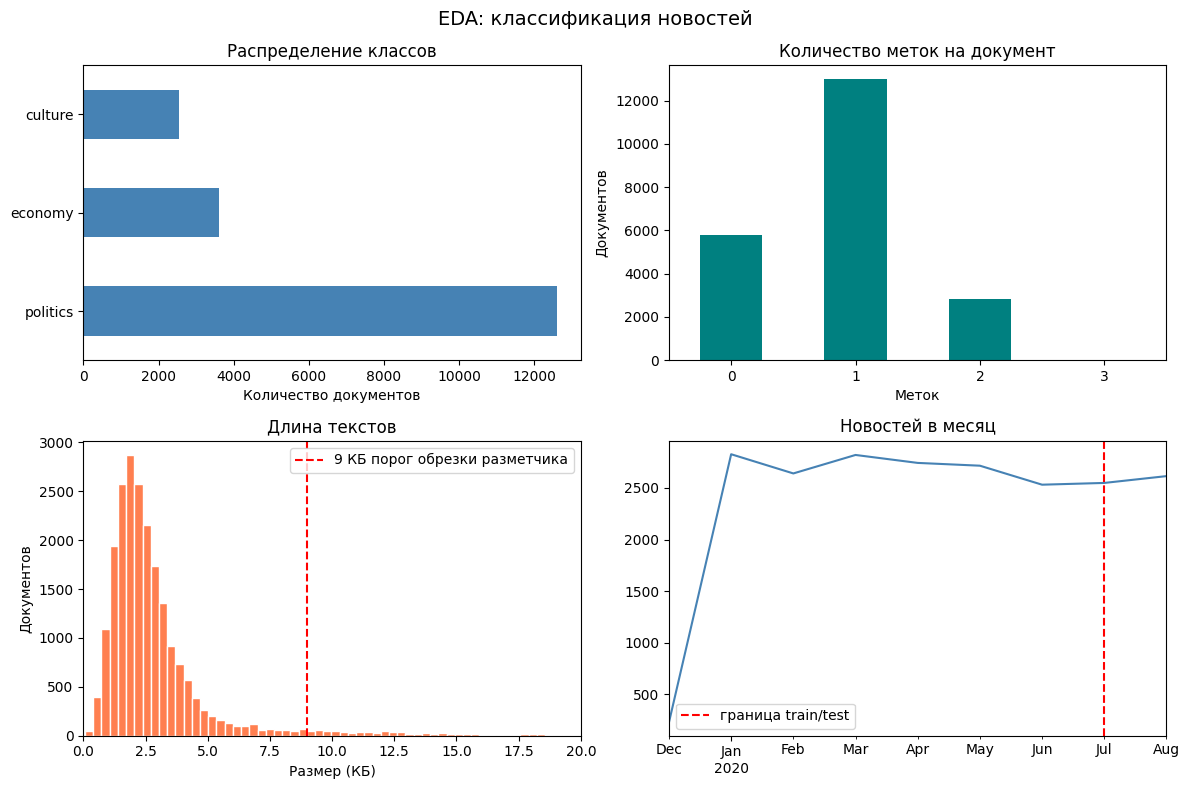


  График сохранён: eda_report.png


has_html         4
has_urls        85
multi_spaces     0
has_newlines     0
dtype: int64

Наблюдения по EDA:
 классы слегка перекошены, но коррекции в случае multilabel не требуется,
 много текстов с 0 меток - в обучение не пускаем, но в валидацию оставляем,
 тексты в основном не очень длинные и поместятся в контекст, 
по количеству новостей в месяц распределение равномерное.
 Временное разделение показалось логичным для имитации реальной ситуации (не смотреть в будущее на обучении) и 
проверки устойчивости модели к дрейфу классов.

In [42]:
# ---- Ваш код здесь ----
print("EDA и разделение на трейн-тест")

# загрузим размеченные данные, чтобы перезапускать ноутбук при необходимости без повторной разметки

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print as rprint

df_labeled = pd.read_csv("labeled_data.csv")
df_labeled['publication_date'] = pd.to_datetime(df_labeled['publication_date'], utc=True, errors='coerce')
rprint(f"Загружено {len(df_labeled)} записей из labeled_data.csv")
rprint(df_labeled.head())


#rprint(df_labeled['politics'].value_counts(normalize=True))
#rprint(df_labeled['economy'].value_counts(normalize=True))
#rprint(df_labeled['culture'].value_counts(normalize=True))
# немного перекошены классы: 60 политика, по 12 экономика и культура.

# Дальше с помощью LLM написана функция анализа и разделения.
# Заодно очистим данные от пустых категорий


#LABEL_COLS = ['politics', 'economy', 'culture', 'technology', 'sports']
LABEL_COLS = ['politics', 'economy', 'culture']

# Доя теста отделим 20% последних по времени. Заодно посмотрим, как изменялись категории между трейном и тестом.

def eda_multilabel(df, text_col='text', label_cols=LABEL_COLS, date_col='publication_date', test_size=0.2):
    """
    EDA и временное разделение для мультилейбл классификации новостей.
    Метки — бинарные колонки (0/1) в df.
    """

    # ── 0. Фильтрация ─────────────────────────────────────────────
    df = df.copy()
    # даты уже распарсены в load_tsv, убираем NaT
    n_bad_dates = df[date_col].isna().sum()
    if n_bad_dates > 0:
        print(f"  Не удалось распарсить дат: {n_bad_dates} — исключены")
        df = df.dropna(subset=[date_col])

    # считаем записи без меток (информационно, не удаляем — пригодятся для тестов)
    label_sums = df[label_cols].sum(axis=1)
    n_no_labels = (label_sums == 0).sum()
    print(f"  Записей без меток (все 0): {n_no_labels}")

    print("=" * 60)
    print("1. БАЗОВАЯ ИНФОРМАЦИЯ")
    print("=" * 60)
    print(f"Всего записей:      {len(df)}")
    print(f"Дубликаты текстов:  {df[text_col].duplicated().sum()}")
    print(f"Пустые тексты:      {df[text_col].isna().sum()}")
    print(f"Диапазон дат:       {df[date_col].min().strftime('%Y-%m-%d')} → {df[date_col].max().strftime('%Y-%m-%d')}")

    # ── 2. Распределение по классам ──────────────────────────────
    print("\n" + "=" * 60)
    print("2. РАСПРЕДЕЛЕНИЕ КЛАССОВ")
    print("=" * 60)
    label_counts = df[label_cols].sum().sort_values(ascending=False)
    for label, count in label_counts.items():
        pct = count / len(df) * 100
        print(f"  {label:<15} {int(count):>6}  ({pct:.1f}% документов)")

    # ── 3. Мультилейбл статистика ────────────────────────────────
    print("\n" + "=" * 60)
    print("3. МУЛЬТИЛЕЙБЛ СТАТИСТИКА")
    print("=" * 60)
    label_counts_per_doc = df[label_cols].sum(axis=1)
    print(f"  0 меток:          {(label_counts_per_doc == 0).sum()} "
          f"({(label_counts_per_doc == 0).mean()*100:.1f}%)")
    print(f"  Только 1 метка:   {(label_counts_per_doc == 1).sum()} "
          f"({(label_counts_per_doc == 1).mean()*100:.1f}%)")
    print(f"  2 метки:          {(label_counts_per_doc == 2).sum()} "
          f"({(label_counts_per_doc == 2).mean()*100:.1f}%)")
    print(f"  3+ метки:         {(label_counts_per_doc >= 3).sum()} "
          f"({(label_counts_per_doc >= 3).mean()*100:.1f}%)")
    print(f"  Среднее меток:    {label_counts_per_doc.mean():.2f}")

    # Совместная встречаемость пар меток
    co_matrix = df[label_cols].T.dot(df[label_cols])
    np.fill_diagonal(co_matrix.values, 0)
    print("\n  Матрица совместной встречаемости:")
    print(co_matrix.to_string())

    # ── 4. Длина текстов ─────────────────────────────────────────
    print("\n" + "=" * 60)
    print("4. ДЛИНА ТЕКСТОВ (байты)")
    print("=" * 60)
    text_sizes = df[text_col].str.encode('utf-8').str.len()
    print(text_sizes.describe().apply(lambda x: f"{x:,.0f}").to_string())
    n_over_9k = (text_sizes > 9_000).sum()
    n_over_20k = (text_sizes > 20_000).sum()
    print(f"\n  Текстов > 9 КБ:  {n_over_9k} ({n_over_9k/len(df)*100:.1f}%)")
    print(f"  Текстов > 20 КБ:  {n_over_20k} ({n_over_20k/len(df)*100:.1f}%)")

    # ── 5. Активность по времени ─────────────────────────────────
    print("\n" + "=" * 60)
    print("5. АКТИВНОСТЬ ПО ВРЕМЕНИ")
    print("=" * 60)
    monthly = df.set_index(date_col).resample('ME').size()
    print(f"  Месяцев в датасете: {len(monthly)}")
    print(f"  Мин. новостей/мес: {monthly.min()} ({monthly.idxmin().strftime('%Y-%m')})")
    print(f"  Макс. новостей/мес: {monthly.max()} ({monthly.idxmax().strftime('%Y-%m')})")

    # ── 6. Временно́е разделение ──────────────────────────────────
    print("\n" + "=" * 60)
    print("6. РАЗДЕЛЕНИЕ НА TRAIN / TEST")
    print("=" * 60)
    df_sorted = df.sort_values(date_col).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1 - test_size))
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df  = df_sorted.iloc[split_idx:].copy()

    split_date = df_sorted.iloc[split_idx][date_col]
    print(f"  Train: {len(train_df)} записей  до   {split_date.strftime('%Y-%m-%d')}")
    print(f"  Test:  {len(test_df)}  записей  с    {split_date.strftime('%Y-%m-%d')}")

    # Проверка: распределение классов в трейне и тесте
    print("\n  Распределение классов (% документов):")
    print(f"  {'Класс':<15} {'Train':>8} {'Test':>8}  {'Δ':>6}")
    for label in label_cols:
        tr_pct = train_df[label].mean() * 100
        te_pct = test_df[label].mean() * 100
        flag = " !" if abs(tr_pct - te_pct) > 5 else ""
        print(f"  {label:<15} {tr_pct:>7.1f}% {te_pct:>7.1f}%  {tr_pct-te_pct:>+5.1f}%{flag}")

    # ── 7. Графики ───────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("EDA: классификация новостей", fontsize=14)

    # Распределение классов
    ax = axes[0, 0]
    label_counts.plot.barh(ax=ax, color='steelblue')
    ax.set_title("Распределение классов")
    ax.set_xlabel("Количество документов")

    # Количество меток на документ
    ax = axes[0, 1]
    label_counts_per_doc.value_counts().sort_index().plot(kind='bar', ax=ax, color='teal')
    ax.set_title("Количество меток на документ")
    ax.set_xlabel("Меток")
    ax.set_ylabel("Документов")
    ax.tick_params(axis='x', rotation=0)

    # Длина текстов
    ax = axes[1, 0]
    text_sizes_kb = text_sizes / 1024
    ax.hist(text_sizes_kb[text_sizes_kb <= 20], bins=60, color='coral', edgecolor='white')
    ax.set_xlim(0, 20)
    ax.axvline(9, color='red', linestyle='--', label='9 КБ порог обрезки разметчика')
    ax.set_title("Длина текстов")
    ax.set_xlabel("Размер (КБ)")
    ax.set_ylabel("Документов")
    ax.legend()

    # Активность по времени с границей трейн/тест
    ax = axes[1, 1]
    monthly.plot(ax=ax, color='steelblue')
    ax.axvline(split_date, color='red', linestyle='--', label='граница train/test')
    ax.set_title("Новостей в месяц")
    ax.set_xlabel("")
    ax.legend()

    plt.tight_layout()
    plt.savefig("eda_report.png", dpi=120, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print("\n  График сохранён: eda_report.png")

    return train_df, test_df

# ── Запуск ───────────────────────────────────────────────────────
print("\nЗапускаем EDA и разделение на трейн-тест...")
train_df, test_df = eda_multilabel(df_labeled)

# сколько мусора в текстах - для BERT важно
def text_quality_check(df, text_col='text'):
    issues = pd.DataFrame()
    issues['has_html']     = df[text_col].str.contains(r'<[a-zA-Z]', regex=True)
    issues['has_urls']     = df[text_col].str.contains(r'https?://', regex=True)
    issues['multi_spaces'] = df[text_col].str.contains(r'  +', regex=True)
    issues['has_newlines'] = df[text_col].str.contains(r'\n{3,}', regex=True)
    rprint(issues.sum())

text_quality_check(df_labeled)

rprint("Наблюдения по EDA:\n классы слегка перекошены, но коррекции в случае multilabel не требуется,\n " \
"много текстов с 0 меток - в обучение не пускаем, но в валидацию оставляем,\n" \
" тексты в основном не очень длинные и поместятся в контекст, \n" \
"по количеству новостей в месяц распределение равномерное.\n " \
"Временное разделение показалось логичным для имитации реальной ситуации (не смотреть в будущее на обучении)" \
" и проверки устойчивости модели к дрейфу классов.")

# ---- Конец кода ----



## 6. Архитектура и пайплайн - 5 баллов

Самое существенное в данном задании - правильно выбрать ML-архитектуру решения. Подумайте, с учетом постановки задачи и целей бизнеса, как стоит построить обучение и инференс вашей модели.

В любом случае вам понадобится какая-то предобученная модель. В случае, если вы остановитесь на BERT-подобной, можно выбрать любую подходящую под задачу отсюда: https://huggingface.co/models?pipeline_tag=feature-extraction&sort=trending. Вспомните, на что стоит ориентироваться при выборе эмбеддера.

Если хочется выбрать BERT полегче, можете посмотреть в сторону такой модели: https://huggingface.co/cointegrated/rubert-tiny2

В качестве ответа:
- опишите, как будет выглядеть пайплайн подготовки данных, обучения и инференса вашей классификации для всех категорий.
- опишите, почему вы выбрали именно такую архитектуру, какие у нее преимущества и какие недостатки.
- если используете предобученную модель, то напишите какую и как ее найти, а также почему вы выбрали именно ее.

In [43]:

# ---- Ваш код здесь ----
rprint("Вот так будет выглядеть пайплайн: " \
"Выбрана модель легкий BERT 'sergeyzh/rubert-tiny-turbo' - по лидерборду выше базового cointegrated/rubert-tiny2, " \
"модель русскоязычная плюс адаптирована под домен (датасеты gazeta и lenta-ru). " \
"Небольшой вес позволит разворачивать в продакшене на CPU. " \
"К модели добавляем классифицирующие линейные слои ('головы') по одному на каждую категорию. " \
"Это позволит добавлять новые категории без риска ухудшения качества существующих.\n\n" \
"Данные:\n" \
"Датасет поделен на обучающую и валидационную выборки 80/20 по принципу даты - более старые данные в обучении, новые в валидации. " \
"Размечен генеративной моделью 8B с высоким порогом " \
"присвоения категории (подбирал экспериментально, просматривая результаты), чтобы в обучающем датасете были только уверенные примеры. " \
"Для обучения используем только примеры с высокой уверенностью, но в валидации оставляем все примеры - как в жизни.\n" \
"(Не уверен, что это верный подход, но классификатор из LLM 8B был не идеальный, я решил шумные данные в обучение не отправлять.)\n\n" \
"Пайплайн обучения:\n" \
"Сначала замораживаем все слои модели, кроме классифицирующих, " \
"3 эпохи обучения с lr=1e-3 для голов на фазе прогрева подгонят головы под энкодер. " \
"Затем размораживаем все слои и продолжаем обучение с меньшим рейтом для адаптации под задачу "
"(низкий lr на энкодер и средний на головы).\n" \
"Используем лосс BCEWithLogitsLoss независимо по каждой голове, что соответствует мультилейбл задаче.\n\n" \
"Инференс:\n" \
"Текст новости чистим как при создании обучающего датасета, подаем на энкодер, " \
"из выходного тензора берем представление [CLS] (первый токен), подаем на классифицирующие головы.\n" \
"Выход каждой головы пропускается через Sigmoid, метка присваивается по порогу (подбирается per-class на валидации)\n\n" \
"Плюсы:\n" \
"- скорость инференса\n" \
"- легкость добавления категорий\n" \
"- готовая адаптация под домен\n" \
"Минусы:\n" \
"- ограничение по размерности энкодера (312 грубее традиционного BERT на 768) может ограничить качество\n" \
"- существенное изменение списка категорий потребует полного дообучения модели, включая энкодер и другие головы.\n\n" \
"Почему это хорошо:\n" \
"Практика разметки датасета показала, что неплохая LLM 8B не идеально классифицирует все категории, " \
"при этом требует GPU для инференса и скорость существенно ниже легкой модели, а дообучить 8B сложно. " \
"Есть надежда, что легкая модель справится не сильно хуже, зато быстрее в продакшене, однако будет видно по MVP.")
# ---- Конец кода ----

Вот так будет выглядеть пайплайн: Выбрана модель легкий BERT 'sergeyzh/rubert-tiny-turbo' - по лидерборду выше 
базового cointegrated/rubert-tiny2, модель русскоязычная плюс адаптирована под домен (датасеты gazeta и lenta-ru). 
Небольшой вес позволит разворачивать в продакшене на CPU. К модели добавляем классифицирующие линейные слои 
('головы') по одному на каждую категорию. Это позволит добавлять новые категории без риска ухудшения качества 
существующих.

Данные:
Датасет поделен на обучающую и валидационную выборки 80/20 по принципу даты - более старые данные в обучении, новые
в валидации. Размечен генеративной моделью 8B с высоким порогом присвоения категории (подбирал экспериментально, 
просматривая результаты), чтобы в обучающем датасете были только уверенные примеры. Для обучения используем только 
примеры с высокой уверенностью, но в валидации оставляем все примеры - как в жизни.
(Не уверен, что это верный подход, но классификатор из LLM 8B был не идеальный, я решил шумные данные в обучение не
отправлять.)

Пайплайн обучения:
Сначала замораживаем все слои модели, кроме классифицирующих, 3 эпохи обучения с lr=1e-3 для голов на фазе прогрева
подгонят головы под энкодер. Затем размораживаем все слои и продолжаем обучение с меньшим рейтом для адаптации под 
задачу (низкий lr на энкодер и средний на головы).
Используем лосс BCEWithLogitsLoss независимо по каждой голове, что соответствует мультилейбл задаче.

Инференс:
Текст новости чистим как при создании обучающего датасета, подаем на энкодер, из выходного тензора берем 
представление [CLS] (первый токен), подаем на классифицирующие головы.
Выход каждой головы пропускается через Sigmoid, метка присваивается по порогу (подбирается per-class на валидации)

Плюсы:
- скорость инференса
- легкость добавления категорий
- готовая адаптация под домен
Минусы:
- ограничение по размерности энкодера (312 грубее традиционного BERT на 768) может ограничить качество
- существенное изменение списка категорий потребует полного дообучения модели, включая энкодер и другие головы.

Почему это хорошо:
Практика разметки датасета показала, что неплохая LLM 8B не идеально классифицирует все категории, при этом требует
GPU для инференса и скорость существенно ниже легкой модели, а дообучить 8B сложно. Есть надежда, что легкая модель
справится не сильно хуже, зато быстрее в продакшене, однако будет видно по MVP.

## 7. Обучение модели - 10 баллов

Реализуйте архитектуру и пайплайн, описанный в предыдущем пункте. Реализуйте все классы и методы, необходимые для обработки данных, обучения и инференса.

Обучите модель предсказывать все указанные категории на полученных вами данных. Не забывайте считать train и val лоссы в процессе обучения. В выводе ячеек крайне желательно отобразить процесс обучения (tqdm или принты с лоссами каждую эпоху).

### Классы для обучения и подготовки данных

In [44]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import os
import joblib


# ---- Ваш код здесь ----
# Co-authored with Claude Opus 4.6, который помог с кодом модели и обучающего цикла, а также объяснил, что тут вообще происходит.

# =====================================================================
# КОНФИГУРАЦИЯ
# =====================================================================
MODEL_NAME_BERT = "sergeyzh/rubert-tiny-turbo"  # легкий русскоязычный BERT, hidden_size=312
MAX_SEQ_LEN = 512          # максимальная длина входа в токенах TODO модель позволяет до 2048, можно поэкспериментировать с увеличением
BATCH_SIZE = 32
LABEL_COLS = ['politics', 'economy', 'culture'] # категории для классификации, соответствуют разметке в датасете
NUM_LABELS = len(LABEL_COLS)

VAL_FILTER = True  # если True, в валидацию пойдут все примеры, включая с 0 меток, если False — только с метками (для проверки влияния шумных данных на валидацию)

# Фазы обучения:
# Фаза 1 — прогрев голов (энкодер заморожен)
WARMUP_EPOCHS = 3
WARMUP_LR = 1e-3

# Фаза 2 — дообучение всей модели
FINETUNE_EPOCHS = 10
FINETUNE_LR_ENCODER = 5e-6   # очень низкий lr для энкодера — чтобы не ломать претрейн
FINETUNE_LR_HEADS = 2e-4     # средний lr для голов
WEIGHT_DECAY = 0.01           # регуляризация для борьбы с переобучением
DROPOUT_RATE = 0.3            # dropout перед головами
EARLY_STOPPING_PATIENCE = 3  # сколько эпох терпим рост val_loss

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

torch.cuda.empty_cache()

# =====================================================================
# DATASET — подготовка данных для PyTorch
# =====================================================================
class NewsDataset(Dataset):
    """
    Датасет для мультилейбл классификации новостей.
    Каждый элемент — токенизированный текст + вектор бинарных меток.
    """
    def __init__(self, df, tokenizer, label_cols, max_len=MAX_SEQ_LEN):
        self.texts = df['text'].fillna('').tolist()
        # метки: берём только нужные колонки, приводим к float для BCEWithLogitsLoss
        self.labels = df[label_cols].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),           # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0), # (max_len,)
            'labels': torch.tensor(self.labels[idx]),                # (num_labels,)
        }


# =====================================================================
# МОДЕЛЬ — BERT-энкодер + независимые классифицирующие головы
# =====================================================================
class MultiLabelNewsClassifier(nn.Module):
    """
    Архитектура:
      - BERT-энкодер (замораживается/размораживается по фазам)
      - Отдельная линейная голова на каждую категорию:
        hidden_size → 1 (без финального sigmoid — используем BCEWithLogitsLoss)
    Отдельные головы позволяют добавлять новые категории
    без риска деградации существующих.
    """
    def __init__(self, model_name, num_labels, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size  # 312 для rubert-tiny-turbo

        # dropout перед головами — регуляризация для борьбы с переобучением
        self.dropout = nn.Dropout(dropout_rate)

        # по одной линейной голове на категорию
        self.heads = nn.ModuleList([
            nn.Linear(hidden_size, 1) for _ in range(num_labels)
        ])

    def freeze_encoder(self):
        """Замораживаем энкодер — обучаются только головы."""
        for param in self.encoder.parameters():
            param.requires_grad = False

    def unfreeze_encoder(self):
        """Размораживаем энкодер — обучается всё."""
        for param in self.encoder.parameters():
            param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        # получаем представление [CLS] (первый токен)
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch, hidden_size)

        # dropout перед головами (активен только в train mode)
        cls_output = self.dropout(cls_output)

        # каждая голова даёт один логит
        logits = torch.cat([head(cls_output) for head in self.heads], dim=1)  # (batch, num_labels)
        return logits

# =====================================================================
# ФУНКЦИИ ОБУЧЕНИЯ И ВАЛИДАЦИИ
# =====================================================================

def train_epoch(model, dataloader, optimizer, criterion, device):
    """Одна эпоха обучения. Возвращает средний лосс."""
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch in tqdm(dataloader, desc="  train", leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

def evaluate(model, dataloader, criterion, device, label_cols):
    """
    Валидация: считаем лосс и метрики per-class.
    Возвращает: (val_loss, metrics_dict)
    """
    model.eval()
    total_loss = 0.0
    num_batches = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="  val", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            num_batches += 1

            # предсказания: sigmoid > 0.5
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    val_loss = total_loss / num_batches
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # метрики per-class
    metrics = {}
    for i, col in enumerate(label_cols):
        p, r, f1, _ = precision_recall_fscore_support(
            all_labels[:, i], all_preds[:, i], average='binary', zero_division=0
        )
        acc = accuracy_score(all_labels[:, i], all_preds[:, i])
        metrics[col] = {'precision': p, 'recall': r, 'f1': f1, 'accuracy': acc}

    return val_loss, metrics

def print_metrics(metrics, label_cols):
    """Вывод метрик в табличном виде."""
    print(f"  {'Категория':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Accuracy':>10}")
    for col in label_cols:
        m = metrics[col]
        print(f"  {col:<15} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f} {m['accuracy']:>10.4f}")


Устройство: cuda


In [45]:

# =====================================================================
# ПОДГОТОВКА ДАННЫХ
# =====================================================================
print("=" * 60)
print("ПОДГОТОВКА ДАННЫХ")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_BERT)

# для обучения берём только записи с хотя бы одной меткой
train_mask = train_df[LABEL_COLS].sum(axis=1) > 0
train_filtered = train_df[train_mask].reset_index(drop=True)
print(f"  Train: {len(train_filtered)} записей (из {len(train_df)}, исключены без меток: {len(train_df) - len(train_filtered)})")
print(f"  Val:   {len(test_df)} записей (все, включая без меток)")

val_filtered = test_df if not VAL_FILTER else test_df[test_df[LABEL_COLS].sum(axis=1) > 0].reset_index(drop=True)
if VAL_FILTER:
    print(f"  Val (после фильтрации): {len(val_filtered)} записей")

train_dataset = NewsDataset(train_filtered, tokenizer, LABEL_COLS)
val_dataset = NewsDataset(val_filtered, tokenizer, LABEL_COLS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =====================================================================
# ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
# =====================================================================
print("\n" + "=" * 60)
print("ИНИЦИАЛИЗАЦИЯ МОДЕЛИ")
print("=" * 60)

model = MultiLabelNewsClassifier(MODEL_NAME_BERT, NUM_LABELS).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()

# считаем параметры
total_params = sum(p.numel() for p in model.parameters())
head_params = sum(p.numel() for p in model.heads.parameters())
print(f"  Энкодер: {MODEL_NAME_BERT}")
print(f"  Всего параметров: {total_params:,}")
print(f"  Параметров в головах: {head_params:,}")
print(f"  Категории: {LABEL_COLS}")

# =====================================================================
# ФАЗА 1 — ПРОГРЕВ ГОЛОВ (энкодер заморожен)
# =====================================================================
print("\n" + "=" * 60)
print("ФАЗА 1: ПРОГРЕВ ГОЛОВ (энкодер заморожен)")
print("=" * 60)

model.freeze_encoder()
# оптимизатор только для голов, с weight decay для регуляризации
optimizer_warmup = torch.optim.AdamW(model.heads.parameters(), lr=WARMUP_LR, weight_decay=WEIGHT_DECAY)

for epoch in range(1, WARMUP_EPOCHS + 1):
    print(f"\n  Эпоха {epoch}/{WARMUP_EPOCHS}")

    train_loss = train_epoch(model, train_loader, optimizer_warmup, criterion, DEVICE)
    val_loss, metrics = evaluate(model, val_loader, criterion, DEVICE, LABEL_COLS)

    print(f"  Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}")
    print_metrics(metrics, LABEL_COLS)

# =====================================================================
# ФАЗА 2 — ДООБУЧЕНИЕ ВСЕЙ МОДЕЛИ
# =====================================================================
print("\n" + "=" * 60)
print("ФАЗА 2: ДООБУЧЕНИЕ ВСЕЙ МОДЕЛИ")
print("=" * 60)

model.unfreeze_encoder()

# раздельные learning rate: очень низкий для энкодера, средний для голов
# weight_decay для регуляризации
optimizer_finetune = torch.optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': FINETUNE_LR_ENCODER, 'weight_decay': WEIGHT_DECAY},
    {'params': model.heads.parameters(),   'lr': FINETUNE_LR_HEADS,   'weight_decay': WEIGHT_DECAY},
])

# косинусный scheduler — плавно снижает lr к нулю за FINETUNE_EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_finetune, T_max=FINETUNE_EPOCHS, eta_min=1e-7
)

best_val_loss = float('inf')
patience_counter = 0  # счётчик для early stopping

for epoch in range(1, FINETUNE_EPOCHS + 1):
    current_lr_enc = optimizer_finetune.param_groups[0]['lr']
    current_lr_head = optimizer_finetune.param_groups[1]['lr']
    print(f"\n  Эпоха {epoch}/{FINETUNE_EPOCHS}  (lr encoder={current_lr_enc:.2e}, heads={current_lr_head:.2e})")

    train_loss = train_epoch(model, train_loader, optimizer_finetune, criterion, DEVICE)
    val_loss, metrics = evaluate(model, val_loader, criterion, DEVICE, LABEL_COLS)
    scheduler.step()

    print(f"  Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}")
    print_metrics(metrics, LABEL_COLS)

    # сохраняем лучшую модель по val loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  -> Лучшая модель сохранена (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  -> Val loss не улучшился ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"  -> Early stopping: val loss не улучшался {EARLY_STOPPING_PATIENCE} эпох подряд")
            break

print(f"\n  Лучший val loss: {best_val_loss:.4f}")

# =====================================================================
# ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ И ФИНАЛЬНАЯ ОЦЕНКА
# =====================================================================
print("\n" + "=" * 60)
print("ФИНАЛЬНАЯ ОЦЕНКА НА ЛУЧШЕЙ МОДЕЛИ")
print("=" * 60)

model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
val_loss, metrics = evaluate(model, val_loader, criterion, DEVICE, LABEL_COLS)
print(f"  Val loss: {val_loss:.4f}")
print_metrics(metrics, LABEL_COLS)



ПОДГОТОВКА ДАННЫХ
  Train: 12830 записей (из 17331, исключены без меток: 4501)
  Val:   4333 записей (все, включая без меток)
  Val (после фильтрации): 3028 записей

ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
  Энкодер: sergeyzh/rubert-tiny-turbo
  Всего параметров: 29,194,707
  Параметров в головах: 939
  Категории: ['politics', 'economy', 'culture']

ФАЗА 1: ПРОГРЕВ ГОЛОВ (энкодер заморожен)

  Эпоха 1/3


  Train loss: 0.3530  |  Val loss: 0.2505
  Категория        Precision     Recall         F1   Accuracy
  politics            0.8823     0.9934     0.9345     0.8956
  economy             0.9494     0.5331     0.6828     0.8963
  culture             0.9625     0.7090     0.8165     0.9429

  Эпоха 2/3


  Train loss: 0.2288  |  Val loss: 0.1931
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9227     0.9824     0.9516     0.9250
  economy             0.9152     0.6467     0.7579     0.9135
  culture             0.9325     0.8140     0.8692     0.9561

  Эпоха 3/3


  Train loss: 0.2000  |  Val loss: 0.1724
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9301     0.9841     0.9564     0.9326
  economy             0.9034     0.6782     0.7748     0.9174
  culture             0.9297     0.8527     0.8895     0.9620

ФАЗА 2: ДООБУЧЕНИЕ ВСЕЙ МОДЕЛИ

  Эпоха 1/10  (lr encoder=5.00e-06, heads=2.00e-04)


  Train loss: 0.1596  |  Val loss: 0.1335
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9478     0.9828     0.9650     0.9465
  economy             0.8693     0.7760     0.8200     0.9287
  culture             0.9342     0.8895     0.9113     0.9690
  -> Лучшая модель сохранена (val_loss=0.1335)

  Эпоха 2/10  (lr encoder=4.88e-06, heads=1.95e-04)


...

  Train loss: 0.1099  |  Val loss: 0.1226
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9613     0.9745     0.9679     0.9515
  economy             0.8605     0.8076     0.8332     0.9323
  culture             0.9303     0.9098     0.9199     0.9716
  -> Val loss не улучшился (1/3)

  Эпоха 8/10  (lr encoder=1.11e-06, heads=4.13e-05)


  Train loss: 0.1071  |  Val loss: 0.1221
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9614     0.9758     0.9685     0.9524
  economy             0.8485     0.8218     0.8349     0.9320
  culture             0.9352     0.9042     0.9195     0.9716
  -> Лучшая модель сохранена (val_loss=0.1221)

  Эпоха 9/10  (lr encoder=5.68e-07, heads=1.92e-05)


  Train loss: 0.1077  |  Val loss: 0.1220
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9610     0.9758     0.9683     0.9521
  economy             0.8586     0.8139     0.8356     0.9330
  culture             0.9319     0.9079     0.9198     0.9716
  -> Лучшая модель сохранена (val_loss=0.1220)

  Эпоха 10/10  (lr encoder=2.20e-07, heads=4.99e-06)


  Train loss: 0.1069  |  Val loss: 0.1220
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9614     0.9762     0.9688     0.9528
  economy             0.8557     0.8139     0.8343     0.9323
  culture             0.9319     0.9079     0.9198     0.9716
  -> Val loss не улучшился (1/3)

  Лучший val loss: 0.1220

ФИНАЛЬНАЯ ОЦЕНКА НА ЛУЧШЕЙ МОДЕЛИ


  Val loss: 0.1220
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9610     0.9758     0.9683     0.9521
  economy             0.8586     0.8139     0.8356     0.9330
  culture             0.9319     0.9079     0.9198     0.9716


In [54]:
# =====================================================================
# ИНФЕРЕНС — функция для предсказания на новых текстах
# =====================================================================
def predict(texts, model=model, tokenizer=tokenizer, label_cols=LABEL_COLS,
            device=DEVICE, threshold=0.5):
    """
    Инференс на списке текстов.
    Возвращает DataFrame с колонками label_cols и значениями 0/1.

    Пайплайн:
      1. Токенизация текста
      2. Прогон через энкодер, берём [CLS]
      3. Подаём на классифицирующие головы
      4. Sigmoid → сравнение с порогом
    """
    model.eval()
    if isinstance(texts, str):
        texts = [texts]

    encodings = tokenizer(
        texts,
        max_length=MAX_SEQ_LEN,
        padding=True,
        truncation=True,
        return_tensors='pt',
    )
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()

    # бинаризация по порогу
    preds = (probs >= threshold).astype(int)
    return pd.DataFrame(preds, columns=label_cols)

# =====================================================================
# ПРОВЕРКА ИНФЕРЕНСА НА НЕСКОЛЬКИХ ПРИМЕРАХ
# =====================================================================
print("\n" + "=" * 60)
print("ПРОВЕРКА ИНФЕРЕНСА НА НЕФИЛЬТРОВАННОЙ ВЫБОРКЕ")
print("=" * 60)

# берём 15 случайных примеров из валидации
sample_texts = test_df['text'].sample(15, random_state=42).tolist()
sample_preds = predict(sample_texts)
for i, text in enumerate(sample_texts):
    print(f"\n  Текст: {text[:100]}...")
    for col in LABEL_COLS:
        print(f"    {col}: {sample_preds.iloc[i][col]}")

print("\nОбучение завершено. Визуально результат очень неплохой. Ниже проанализируем точнее")

# Сохранить обученную модель и токенизатор на диск для использования в продакшене
# state_dict — веса модели, загружается через model.load_state_dict()
# map_location='cpu' при загрузке на CPU: torch.load("llmpro1_model.pt", map_location='cpu')
torch.save(model.state_dict(), "llmpro1_model.pt")
tokenizer.save_pretrained("llmpro1_tokenizer")

# Конфиг модели: всё, что нужно для восстановления архитектуры и инференса
# - encoder_name: чтобы создать MultiLabelNewsClassifier с тем же энкодером
# - label_cols: порядок категорий = порядок голов в ModuleList
# - dropout_rate: для воспроизведения архитектуры
# - optimal_thresholds: для инференса без пересчёта (будут заполнены после evaluate)
model_config = {
    'encoder_name': MODEL_NAME_BERT,
    'label_cols': LABEL_COLS,
    'dropout_rate': DROPOUT_RATE,
    'max_seq_len': MAX_SEQ_LEN,
    'optimal_thresholds': {},  # заполним после evaluate_heads_with_plots_and_roc
}
joblib.dump(model_config, "llmpro1_config.joblib")
rprint("Сохранено: llmpro1_model.pt, llmpro1_tokenizer/, llmpro1_config.joblib")

# ---- Конец кода ----


ПРОВЕРКА ИНФЕРЕНСА НА НЕФИЛЬТРОВАННОЙ ВЫБОРКЕ

  Текст: МОСКВА, 10 авг — РИА Новости. Актриса Екатерина Волкова (из популярного сериала "Воронины") восхитил...
    politics: 0
    economy: 0
    culture: 1

  Текст: ПЕКИН, 25 июл — РИА Новости. Китай за минувшие сутки выявил 34 новых случая коронавируса и 74 бессим...
    politics: 1
    economy: 0
    culture: 0

  Текст: Российские ретейлеры не верят в рост доходов населения. Они решили сделать ставку на низший ценовой ...
    politics: 0
    economy: 1
    culture: 0

  Текст: МОСКВА, 11 июл — РИА Новости. Число скончавшихся от коронавируса нового типа в Бразилии превысило 70...
    politics: 1
    economy: 1
    culture: 0

  Текст: Китай запустил баллистические ракеты средней дальности DF-26 и DF-21 после инцидента с вторжением ам...
    politics: 1
    economy: 0
    culture: 0

  Текст: Министр иностранных дел Сергей Лавров на встрече с первым заместителем госсекретаря США Стивеном Биг...
    politics: 1
    economy: 0
    cult

Сохранено: llmpro1_model.pt, llmpro1_tokenizer/, llmpro1_config.joblib

## 8. Оценка и интерпретация - 5 баллов

Постройте и посчитайте следующие вещи на тесте для каждой категории:
- Графики: roc-кривую, распределение вероятностей для класса 1 и 0 (на одном графике), confusion matrix
- Метрики: precision, recall, f1 при оптимально подобранном пороге, roc auc


ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ


Модель загружена из файла на cpu


Категория: politics  (порог=0.89)
  Precision: 0.8592
  Recall:    0.9295
  F1:        0.8930
  Accuracy:  0.8832
  ROC AUC:   0.9637

Категория: economy  (порог=0.82)
  Precision: 0.6778
  Recall:    0.7035
  F1:        0.6904
  Accuracy:  0.9077
  ROC AUC:   0.9379

Категория: culture  (порог=0.90)
  Precision: 0.6430
  Recall:    0.8158
  F1:        0.7192
  Accuracy:  0.9201
  ROC AUC:   0.9615

  Графики сохранены: eval_results/evaluation_plots.png


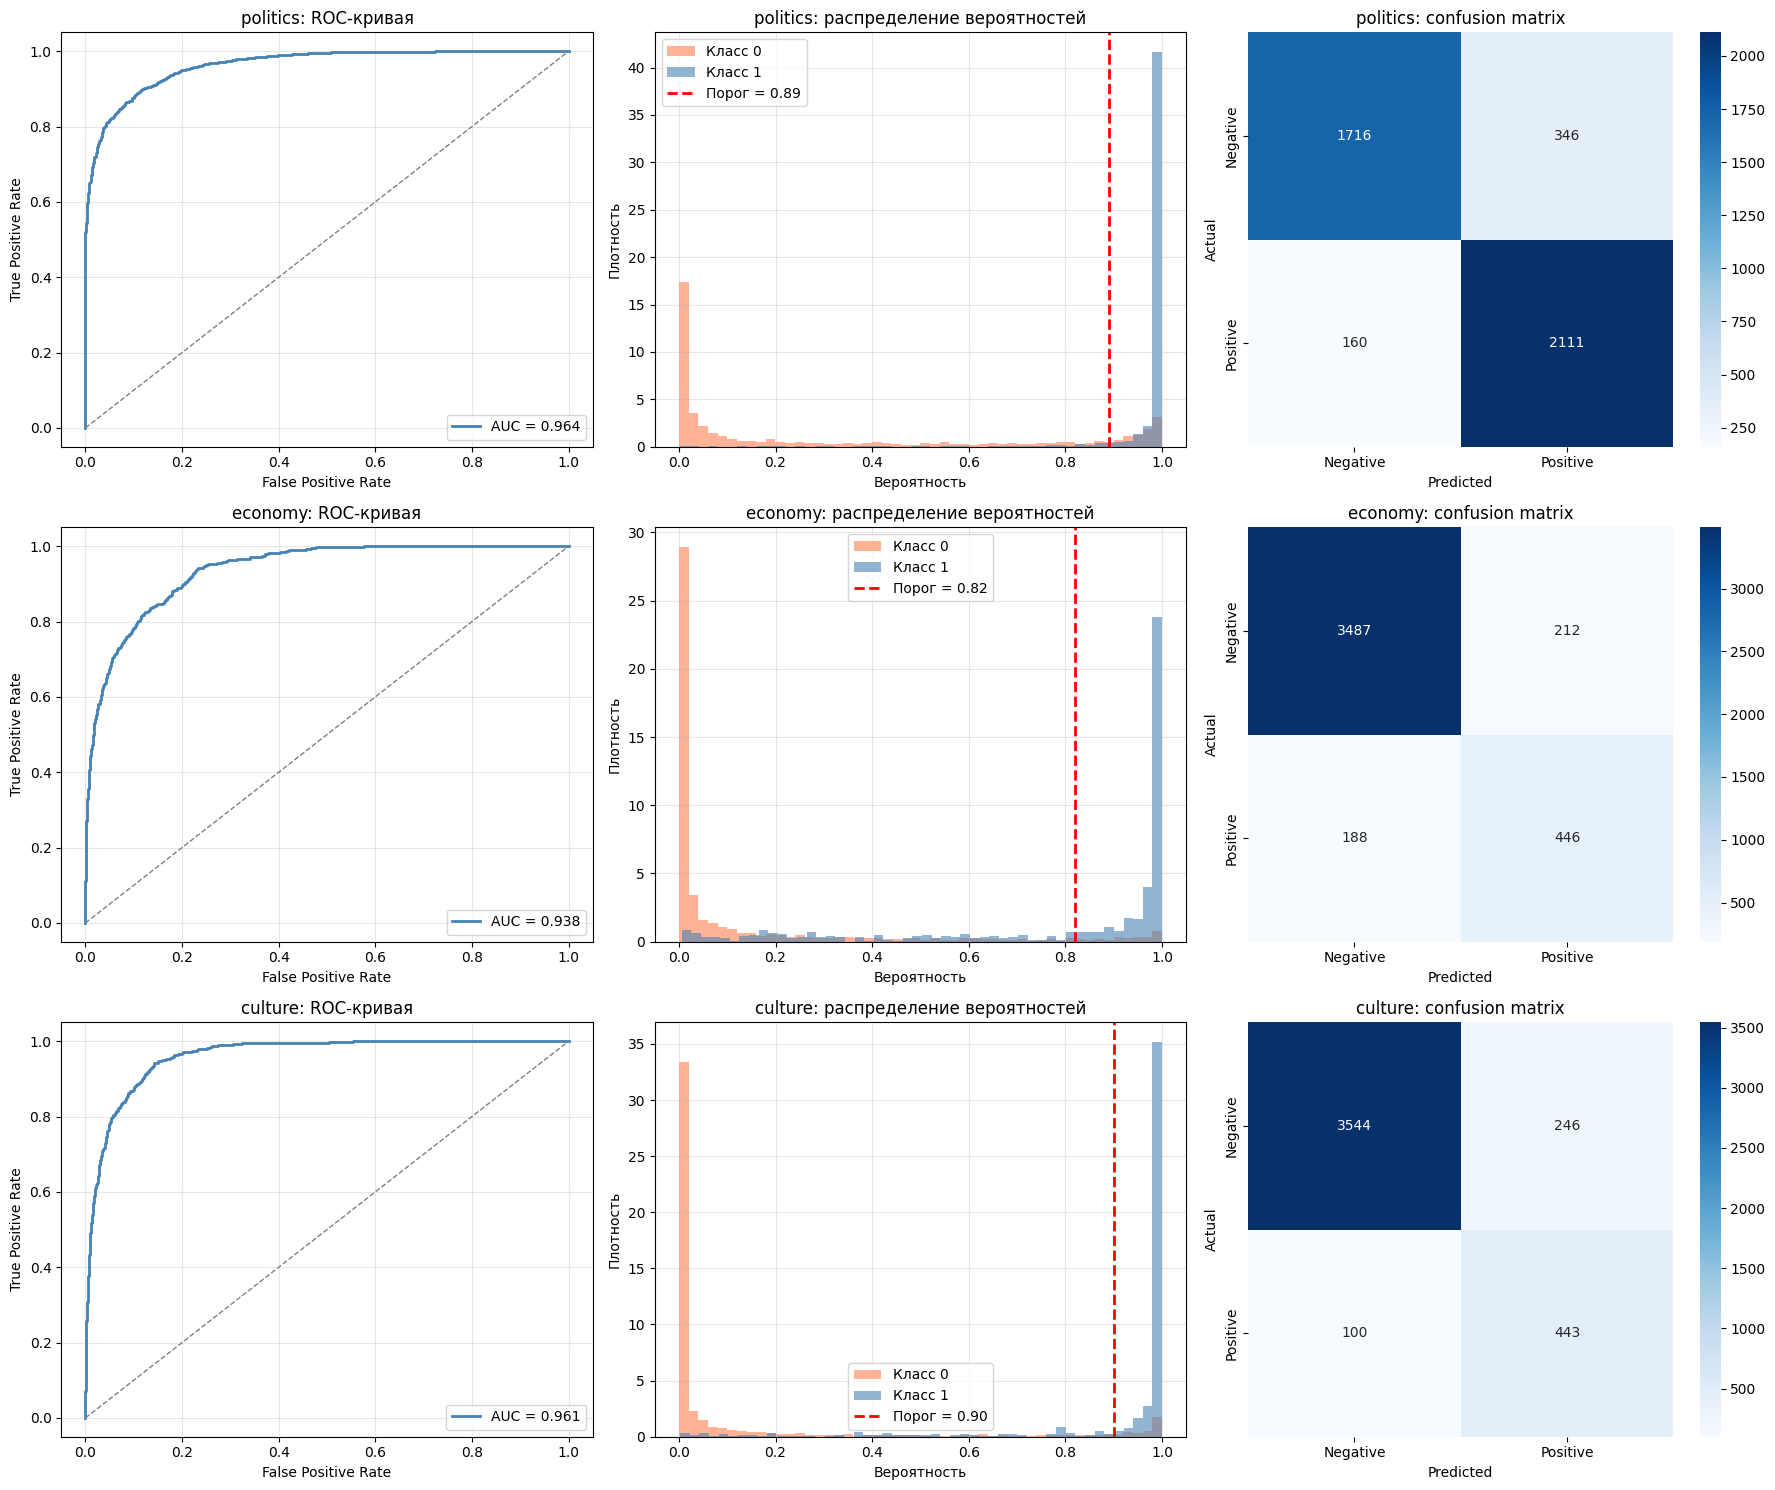


АГРЕГИРОВАННЫЕ МЕТРИКИ
  Macro Precision: 0.7267
  Macro Recall:    0.8163
  Macro F1:        0.7675
  Micro Precision: 0.7886
  Micro Recall:    0.8701
  Micro F1:        0.8274
  Exact Match:     0.7355
  Не классифицировано (на ручную проверку): 748/4333 (17.3%)

  Оптимальные пороги: {'politics': np.float64(0.8899999999999996), 'economy': np.float64(0.8199999999999996), 'culture': np.float64(0.8999999999999996)}


Время оценки на CPU: 50.7 сек, 4333 записей, 11.7 мс/запись

Итоговая таблица метрик:

category  threshold  precision   recall  f1_score  accuracy  auc_roc
    politics       0.89   0.859178 0.929546  0.892978  0.883222 0.963672
     economy       0.82   0.677812 0.703470  0.690402  0.907685 0.937931
     culture       0.90   0.642961 0.815838  0.719156  0.920148 0.961499
   MACRO_AVG        NaN   0.726650 0.816285  0.767512  0.735518      NaN
   MICRO_AVG        NaN   0.788644 0.870070  0.827358  0.735518      NaN
UNCLASSIFIED        NaN        NaN      NaN       NaN       NaN 0.172629

Оптимальные пороги сохранены в llmpro1_config.joblib: {'politics': 0.8899999999999996, 'economy': 
0.8199999999999996, 'culture': 0.8999999999999996}


ОЦЕНКА МОДЕЛИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ



Категория: politics  (порог=0.56)
  Precision: 0.9667
  Recall:    0.9718
  F1:        0.9693
  Accuracy:  0.9538
  ROC AUC:   0.9876

Категория: economy  (порог=0.51)
  Precision: 0.8624
  Recall:    0.8107
  F1:        0.8358
  Accuracy:  0.9333
  ROC AUC:   0.9762

Категория: culture  (порог=0.52)
  Precision: 0.9370
  Recall:    0.9042
  F1:        0.9203
  Accuracy:  0.9719
  ROC AUC:   0.9932

  Графики сохранены: eval_results/evaluation_plots.png


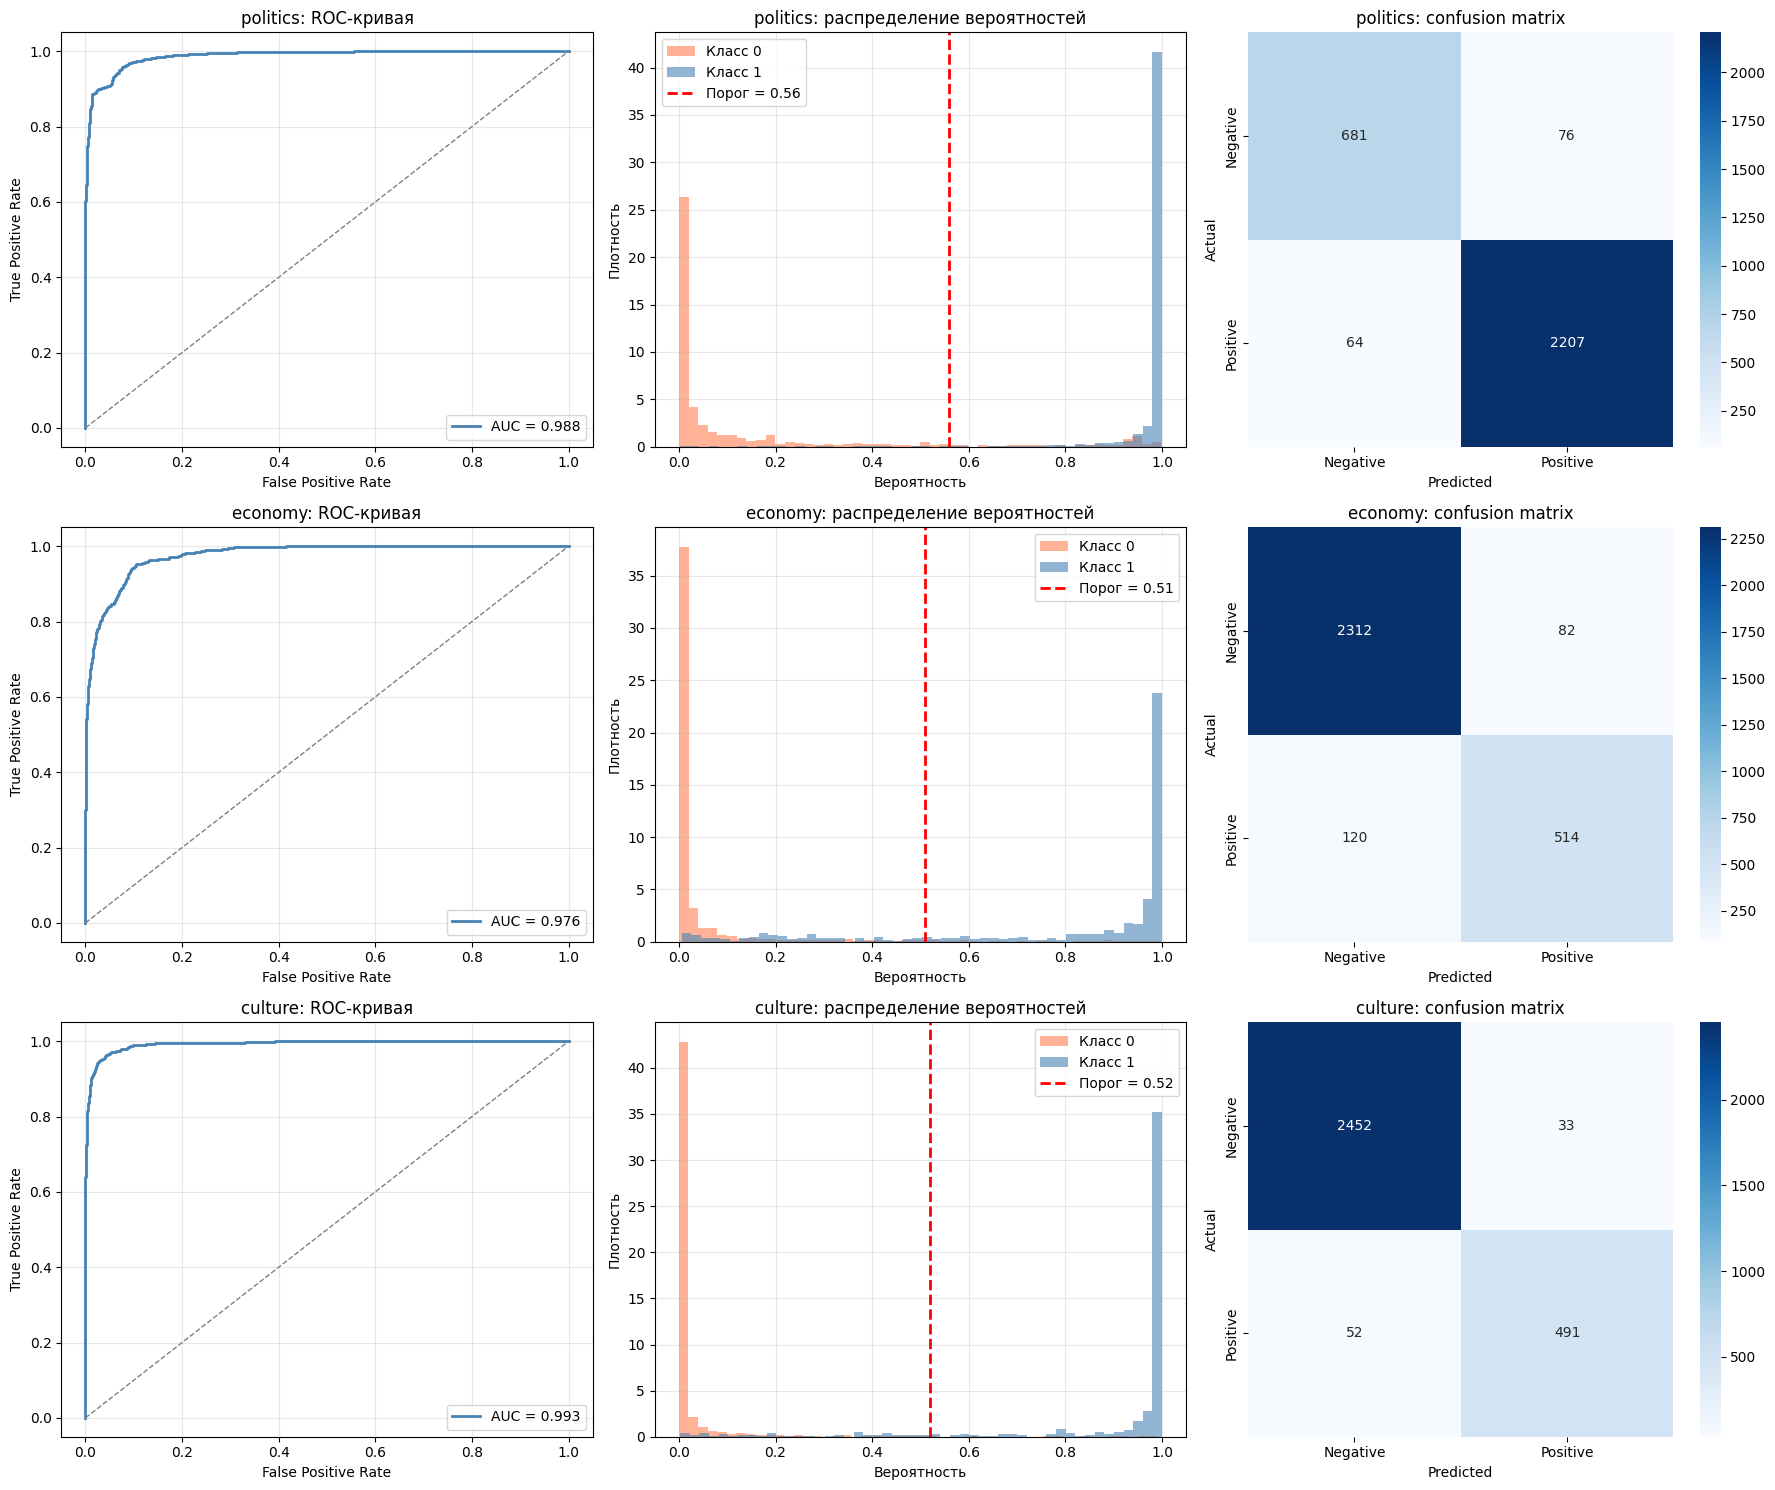


АГРЕГИРОВАННЫЕ МЕТРИКИ
  Macro Precision: 0.9220
  Macro Recall:    0.8956
  Macro F1:        0.9085
  Micro Precision: 0.9439
  Micro Recall:    0.9316
  Micro F1:        0.9377
  Exact Match:     0.8785
  Не классифицировано (на ручную проверку): 17/3028 (0.6%)

  Оптимальные пороги: {'politics': np.float64(0.5599999999999997), 'economy': np.float64(0.5099999999999998), 'culture': np.float64(0.5199999999999998)}


Таблица метрик для валидационной выборки:

category  threshold  precision   recall  f1_score  accuracy  auc_roc
    politics       0.56   0.966710 0.971819  0.969258  0.953765 0.987580
     economy       0.51   0.862416 0.810726  0.835772  0.933289 0.976239
     culture       0.52   0.937023 0.904236  0.920337  0.971929 0.993183
   MACRO_AVG        NaN   0.922050 0.895593  0.908456  0.878468      NaN
   MICRO_AVG        NaN   0.943873 0.931555  0.937673  0.878468      NaN
UNCLASSIFIED        NaN        NaN      NaN       NaN       NaN 0.005614

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---- Ваш код здесь ----

# МЕТРИКИ И ГРАФИКИ

def get_all_predictions(model, dataloader, device):
    """
    Прогоняем модель по всему dataloader, собираем вероятности и истинные метки.
    Возвращает: (all_probs, all_labels) — numpy массивы (N, num_labels)
    """
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="  predict", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    return np.vstack(all_probs), np.vstack(all_labels)


def find_optimal_threshold(y_true, y_probs):
    """
    Подбор оптимального порога по максимуму F1 на валидации.
    Перебираем пороги от 0.1 до 0.9 с шагом 0.01.
    """
    best_f1 = 0.0
    best_thr = 0.5
    for thr in np.arange(0.1, 0.91, 0.01):
        preds = (y_probs >= thr).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, preds, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1


def evaluate_heads_with_plots_and_roc(
    model,
    dataloader,
    device,
    label_cols: list,
    threshold: float = 0.5,       # дефолтный порог (если не подбирать оптимальный)
    optimize_threshold: bool = True,  # подбирать ли оптимальный порог per-class
    verbose: bool = True,
    save_path: str = None
):
    """
    Полная оценка мультилейбл классификатора на тестовых данных.

    Для каждой категории строит:
      - ROC-кривую с AUC
      - Распределение вероятностей для класса 0 и 1
      - Confusion matrix

    Считает метрики:
      - Precision, Recall, F1 per-class (с оптимальным порогом)
      - ROC AUC per-class
      - Macro/Micro F1
      - Общая accuracy
      - Доля "отправленных на ручную проверку" (ни одна метка не назначена)

    Возвращает: DataFrame с метриками per-class + сводная строка.
    """
    # ── 1. Получаем вероятности и метки ──────────────────────────
    all_probs, all_labels = get_all_predictions(model, dataloader, device)
    num_samples = len(all_labels)

    # ── 2. Per-class анализ ──────────────────────────────────────
    metrics_list = []
    optimal_thresholds = {}

    # по 3 графика на категорию: ROC, распределение вероятностей, confusion matrix
    n_cats = len(label_cols)
    fig, axes = plt.subplots(n_cats, 3, figsize=(18, 5 * n_cats))
    if n_cats == 1:
        axes = axes[np.newaxis, :]  # чтобы индексация работала единообразно

    for i, category in enumerate(label_cols):
        y_true = all_labels[:, i]
        y_probs = all_probs[:, i]

        # --- подбор оптимального порога ---
        if optimize_threshold:
            opt_thr, opt_f1 = find_optimal_threshold(y_true, y_probs)
        else:
            opt_thr = threshold
        optimal_thresholds[category] = opt_thr
        y_pred = (y_probs >= opt_thr).astype(int)

        # --- метрики ---
        pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_probs) if y_true.sum() > 0 else 0.0

        metrics_list.append({
            'category': category,
            'threshold': opt_thr,
            'precision': pr,
            'recall': rc,
            'f1_score': f1,
            'accuracy': acc,
            'auc_roc': auc,
        })

        if verbose:
            print(f"\n{'='*50}")
            print(f"Категория: {category}  (порог={opt_thr:.2f})")
            print(f"{'='*50}")
            print(f"  Precision: {pr:.4f}")
            print(f"  Recall:    {rc:.4f}")
            print(f"  F1:        {f1:.4f}")
            print(f"  Accuracy:  {acc:.4f}")
            print(f"  ROC AUC:   {auc:.4f}")

        # --- График 1: ROC-кривая ---
        ax = axes[i, 0]
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
        ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{category}: ROC-кривая')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)

        # --- График 2: распределение вероятностей для класса 0 и 1 ---
        ax = axes[i, 1]
        ax.hist(y_probs[y_true == 0], bins=50, alpha=0.6, color='coral', label='Класс 0', density=True)
        ax.hist(y_probs[y_true == 1], bins=50, alpha=0.6, color='steelblue', label='Класс 1', density=True)
        ax.axvline(opt_thr, color='red', linestyle='--', lw=2, label=f'Порог = {opt_thr:.2f}')
        ax.set_xlabel('Вероятность')
        ax.set_ylabel('Плотность')
        ax.set_title(f'{category}: распределение вероятностей')
        ax.legend()
        ax.grid(alpha=0.3)

        # --- График 3: confusion matrix ---
        ax = axes[i, 2]
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{category}: confusion matrix')

    plt.tight_layout()
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f"{save_path}/evaluation_plots.png", dpi=150, bbox_inches='tight')
        print(f"\n  Графики сохранены: {save_path}/evaluation_plots.png")
    plt.show()
    plt.close(fig)

    # ── 3. Агрегированные метрики ────────────────────────────────
    metrics_df = pd.DataFrame(metrics_list)

    # бинарные предсказания со своим порогом для каждой категории
    all_preds = np.zeros_like(all_probs, dtype=int)
    for i, category in enumerate(label_cols):
        all_preds[:, i] = (all_probs[:, i] >= optimal_thresholds[category]).astype(int)

    # Macro F1 — среднее F1 по категориям (равный вес каждой категории)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    # Micro F1 — по всем предсказаниям сразу (вес пропорционален кол-ву примеров)
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='micro', zero_division=0
    )

    # Общая accuracy — доля полностью правильно классифицированных новостей
    # (все метки совпали)
    exact_match = (all_preds == all_labels).all(axis=1).mean()

    # Доля не классифицированных — ни одна метка не назначена (отправлены на ручную проверку)
    no_label_mask = all_preds.sum(axis=1) == 0
    unclassified_rate = no_label_mask.mean()

    if verbose:
        print(f"\n{'='*50}")
        print("АГРЕГИРОВАННЫЕ МЕТРИКИ")
        print(f"{'='*50}")
        print(f"  Macro Precision: {macro_p:.4f}")
        print(f"  Macro Recall:    {macro_r:.4f}")
        print(f"  Macro F1:        {macro_f1:.4f}")
        print(f"  Micro Precision: {micro_p:.4f}")
        print(f"  Micro Recall:    {micro_r:.4f}")
        print(f"  Micro F1:        {micro_f1:.4f}")
        print(f"  Exact Match:     {exact_match:.4f}")
        print(f"  Не классифицировано (на ручную проверку): {no_label_mask.sum()}/{num_samples} ({unclassified_rate:.1%})")
        print(f"\n  Оптимальные пороги: {optimal_thresholds}")

    # добавляем сводную строку в таблицу метрик
    summary_row = pd.DataFrame([{
        'category': 'MACRO_AVG',
        'threshold': np.nan,
        'precision': macro_p,
        'recall': macro_r,
        'f1_score': macro_f1,
        'accuracy': exact_match,
        'auc_roc': np.nan,
    }, {
        'category': 'MICRO_AVG',
        'threshold': np.nan,
        'precision': micro_p,
        'recall': micro_r,
        'f1_score': micro_f1,
        'accuracy': exact_match,
        'auc_roc': np.nan,
    }, {
        'category': 'UNCLASSIFIED',
        'threshold': np.nan,
        'precision': np.nan,
        'recall': np.nan,
        'f1_score': np.nan,
        'accuracy': np.nan,
        'auc_roc': unclassified_rate,
    }])
    metrics_df = pd.concat([metrics_df, summary_row], ignore_index=True)

    return metrics_df


# ── Запуск оценки ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)

# проверять будем на нефильтрованной валидации, чтобы видеть влияние шумных данных
test_dataset = NewsDataset(test_df, tokenizer, LABEL_COLS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# загрузить обученную модель из файла на CPU для оценки (как в продакшене)
import time

eval_device = torch.device('cpu')
config = joblib.load("llmpro1_config.joblib")
eval_model = MultiLabelNewsClassifier(
    config['encoder_name'], len(config['label_cols']), config['dropout_rate']
)
eval_model.load_state_dict(torch.load("llmpro1_model.pt", map_location=eval_device))
eval_model.to(eval_device)
eval_model.eval()
rprint(f"Модель загружена из файла на {eval_device}")

t_start = time.time()

metrics_df = evaluate_heads_with_plots_and_roc(
    model=eval_model,
    dataloader=test_loader,
    device=eval_device,
    label_cols=LABEL_COLS,
    optimize_threshold=True,
    verbose=True,
    save_path="eval_results",
)
t_end = time.time()
elapsed = t_end - t_start
n_samples = len(test_df)
rprint(f"\nВремя оценки на CPU: {elapsed:.1f} сек, {n_samples} записей, {elapsed/n_samples*1000:.1f} мс/запись")

rprint("\nИтоговая таблица метрик:")
rprint(metrics_df.to_string(index=False))

# сохраняем оптимальные пороги в конфиг для инференса
per_class = metrics_df[metrics_df['category'].isin(LABEL_COLS)]
optimal_thresholds = dict(zip(per_class['category'], per_class['threshold']))
model_config['optimal_thresholds'] = optimal_thresholds
joblib.dump(model_config, "llmpro1_config.joblib")
rprint(f"Оптимальные пороги сохранены в llmpro1_config.joblib: {optimal_thresholds}")

# ДЛЯ ОЦЕНКИ ВЛИЯНИЯ ШУМНЫХ ДАННЫХ НА ВАЛИДАЦИЮ — сравнение с фильтрацией и без

print("\n" + "=" * 60)
print("ОЦЕНКА МОДЕЛИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ")
print("=" * 60)

metrics_df = evaluate_heads_with_plots_and_roc(
    model=eval_model,
    dataloader=val_loader,
    device=eval_device,
    label_cols=LABEL_COLS,
    optimize_threshold=True,
    verbose=True,
    save_path="eval_results",
)
rprint("\nТаблица метрик для валидационной выборки:")
rprint(metrics_df.to_string(index=False))


# ---- Конец кода ----




Результаты тестирования на нефильтованных данных по сравнению с исходными требованиями бизнеса слегка удручают.

| Метрика                  | Требование     | Факт           | Статус           |
|--------------------------|----------------|----------------|------------------|
| Ручная проверка          | < 15%          | 17.3%          | ❌ чуть хуже     |
| Жалобы                   | < 1%           | не измеримо    | ❓               |
| Latency                  | < 1 сек        | 11.8 мс        | ✅               |
| Throughput               | > 5000/час     | ~305,000/час   | ✅               |
| Стоимость                | < $0.001       | ~$0.0000003    | ✅               |
| CTR                      | без ухудшения  | не измеримо    | ❓               |
| Точность классификации   | > 90%          | 79% Micro      | ❌               |
| Полнота классификации    | > 85%          | 87% Micro      | ✅               |

Однако на фильтрованных данных, для которых исходная разметка была качественной и на которой проводилось обучение, результат другой:
| Метрика              | Требование | Реальные данные | Валидация (образцовая) |
|----------------------|------------|-----------------|------------------------|
| Ручная проверка      | < 15%      | 17.3% ❌        | 0.6% ✅                |
| Точность (1 - FP)    | > 90%      | 79% Micro ❌    | 94.4% Micro ✅         |
| Полнота              | > 85%      | 87% Micro ✅    | 93.2% Micro ✅         |

Делаем вывод: надо хорошо размечать данные для обучения. Попробую сделать ниже, в разделе улучшения.

На CPU модель работает уверенно, 70 процентов загрузки i-12600, задержка 12мс на один запрос.

## 9. Деплой и мониторинг, A/B - 2 балла

Опишите, как вы будете выкатывать в модель в прод:
- как будет выглядеть пайплайн от момента, когда вам пришел текст и заголовок новости, до передачи вердиктов по категориям новости.
- как вы распределите железо для инференса: будет использоваться GPU или CPU (или какая-то комбинация), и как вы это обоснуете.
- как бы вы проводили A/B тест с учетом вашего ML и бизнес-целей? Что бы замеряли? Как бы делили на группы? Как измеряли бы значимость изменений?
- как бы вы настраивали мониторинг? Что бы отслеживали? Для чего бы вы это делали?

In [ ]:

# ---- Ваш код здесь ----
print("вот так будет выглядеть деплой, вот это на GPU или CPU, а вот это будем мониторить")
# ---- Конец кода ----

## 10. Итерации улучшения - 3 балла

Проанализируйте внимательно ваше решение, какие в нем есть проблемы и что можно улучшить. Придумайте (сами) максимально полный список того, что можно в модели сделать по-другому и улучшить, чтобы повысить качество модели.

**При желании** (это не повлияет на оценку), выберите одно из таких улучшений, внедрите, после чего выведите в одной ячейке метрики на тесте вашего прошлого и нового решений -- удалось ли улучшить результат?

Обученная модель показала хорошие результаты на искусственно созданной выборке, но плохие на реальных данных. Разметка на первом этапе оказалась шумной. Ручной контроль показал необходимость улучшения разметки. Либо используем более умную модель для автоматической разметки, либо пытаемся улучшить разметку вручную. Попробую подобрать пороги для разных категорий в исходной разметке, для этого сохранил ответы модели в процентах уверенности по каждой категории.После этого снова обучим модель с улучшенной разметкой.
УЛУЧШЕНИЕ РАЗМЕТКИ И ПОДГОТОВКА ДАННЫХ


Загружено 21664 записей из labeled_data_orig.csv

Старая разметка (до пересчёта):

politics: 12606 положительных из 21664

economy: 3606 положительных из 21664

...

culture: 3796 положительных из 21664  (порог 60%)

technology: 2533 положительных из 21664  (порог 50%)

sports: 1347 положительных из 21664  (порог 40%)

Сохранено в labeled_data.csv


Запускаем EDA и разделение на трейн-тест...
  Записей без меток (все 0): 4100
1. БАЗОВАЯ ИНФОРМАЦИЯ
Всего записей:      21664
Дубликаты текстов:  3
Пустые тексты:      0
Диапазон дат:       2019-12-23 → 2020-08-31

2. РАСПРЕДЕЛЕНИЕ КЛАССОВ
  politics         12606  (58.2% документов)
  economy           5670  (26.2% документов)
  culture           3796  (17.5% документов)

3. МУЛЬТИЛЕЙБЛ СТАТИСТИКА
  0 меток:          4100 (18.9%)
  Только 1 метка:   13095 (60.4%)
  2 метки:          4430 (20.4%)
  3+ метки:         39 (0.2%)
  Среднее меток:    1.02

  Матрица совместной встречаемости:
          politics  economy  culture
politics         0     3589      857
economy       3589        0      101
culture        857      101        0

4. ДЛИНА ТЕКСТОВ (байты)
count    21,664
mean      3,117
std       3,301
min          68
25%       1,678
50%       2,339
75%       3,319
max      84,357

  Текстов > 9 КБ:  925 (4.3%)
  Текстов > 20 КБ:  125 (0.6%)

5. АКТИВНОСТЬ ПО ВРЕМЕНИ
  Месяцев в дат

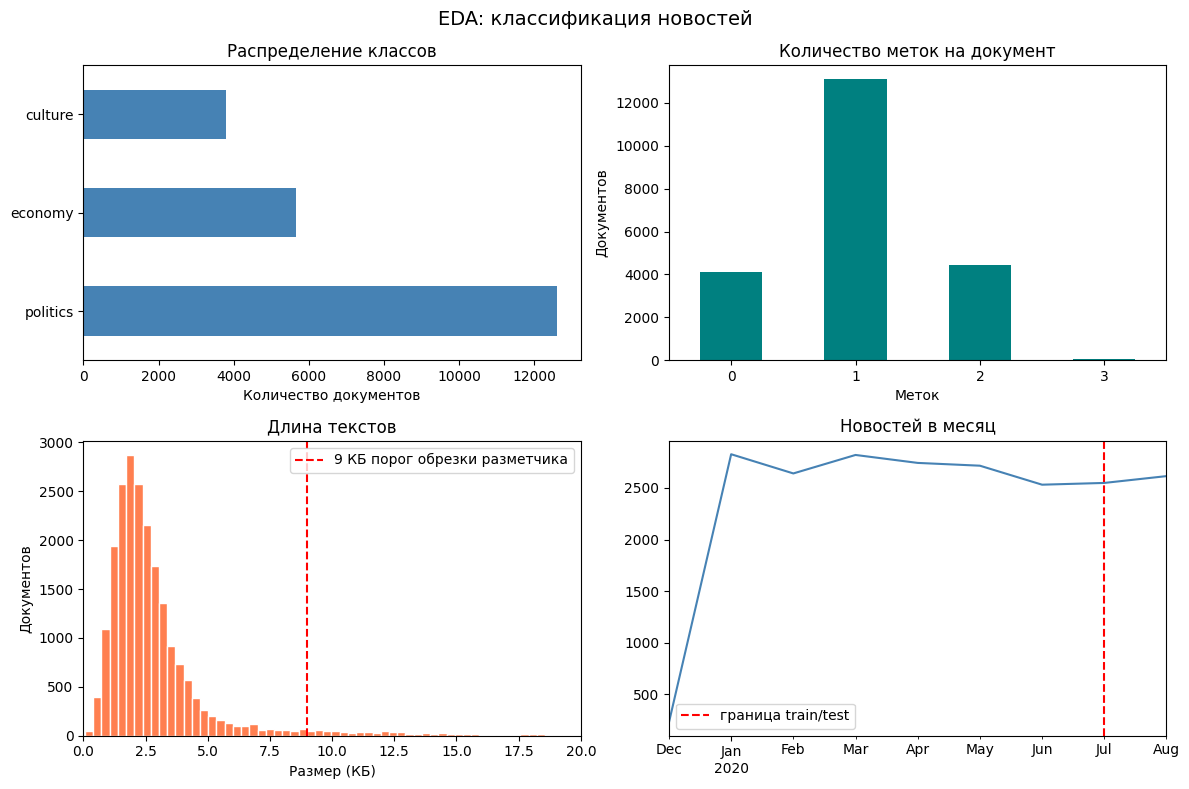


  График сохранён: eda_report.png
  Train: 17331 записей (из 17331, исключены без меток: 0)
  Val:   4333 записей (все, включая без меток)

ИНИЦИАЛИЗАЦИЯ МОДЕЛИ (v2)
  Энкодер: sergeyzh/rubert-tiny-turbo
  Всего параметров: 29,194,707
  Параметров в головах: 939
  Категории: ['politics', 'economy', 'culture']

ФАЗА 1: ПРОГРЕВ ГОЛОВ (энкодер заморожен)

  Эпоха 1/3


  Train loss: 0.4124  |  Val loss: 0.2890
  Категория        Precision     Recall         F1   Accuracy
  politics            0.8814     0.9225     0.9015     0.8943
  economy             0.9315     0.5827     0.7169     0.8934
  culture             0.9316     0.6511     0.7665     0.9234

  Эпоха 2/3


  Train loss: 0.3006  |  Val loss: 0.2377
  Категория        Precision     Recall         F1   Accuracy
  politics            0.8914     0.9216     0.9063     0.9001
  economy             0.9056     0.6594     0.7631     0.9051
  culture             0.9282     0.6953     0.7951     0.9308

  Эпоха 3/3


  Train loss: 0.2766  |  Val loss: 0.2183
  Категория        Precision     Recall         F1   Accuracy
  politics            0.8919     0.9265     0.9089     0.9026
  economy             0.9017     0.6763     0.7729     0.9079
  culture             0.9050     0.7515     0.8211     0.9368

ФАЗА 2: ДООБУЧЕНИЕ ВСЕЙ МОДЕЛИ

  Эпоха 1/10  (lr encoder=5.00e-06, heads=2.00e-04)


  Train loss: 0.2346  |  Val loss: 0.1762
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9056     0.9291     0.9172     0.9121
  economy             0.8499     0.7898     0.8188     0.9190
  culture             0.8767     0.8244     0.8498     0.9437
  -> Лучшая модель сохранена (val_loss=0.1762)

  Эпоха 2/10  (lr encoder=4.88e-06, heads=1.95e-04)


...

  Train loss: 0.1682  |  Val loss: 0.1625
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9263     0.9243     0.9253     0.9218
  economy             0.8568     0.8108     0.8332     0.9248
  culture             0.8892     0.8339     0.8607     0.9478
  -> Лучшая модель сохранена (val_loss=0.1625)

  Лучший val loss: 0.1625

СОХРАНЕНИЕ МОДЕЛИ v2


Сохранено: final_model_v2.pt, final_tokenizer_v2/, model_config_v2.joblib


ОЦЕНКА МОДЕЛИ v2 НА ТЕСТОВОЙ ВЫБОРКЕ (CPU)


Модель v2 загружена из файла на cpu


Категория: politics  (порог=0.55)
  Precision: 0.9377
  Recall:    0.9146
  F1:        0.9260
  Accuracy:  0.9234
  ROC AUC:   0.9801

Категория: economy  (порог=0.50)
  Precision: 0.8568
  Recall:    0.8108
  F1:        0.8332
  Accuracy:  0.9248
  ROC AUC:   0.9702

Категория: culture  (порог=0.61)
  Precision: 0.9223
  Recall:    0.8088
  F1:        0.8619
  Accuracy:  0.9499
  ROC AUC:   0.9834

  Графики сохранены: eval_results_v2/evaluation_plots.png


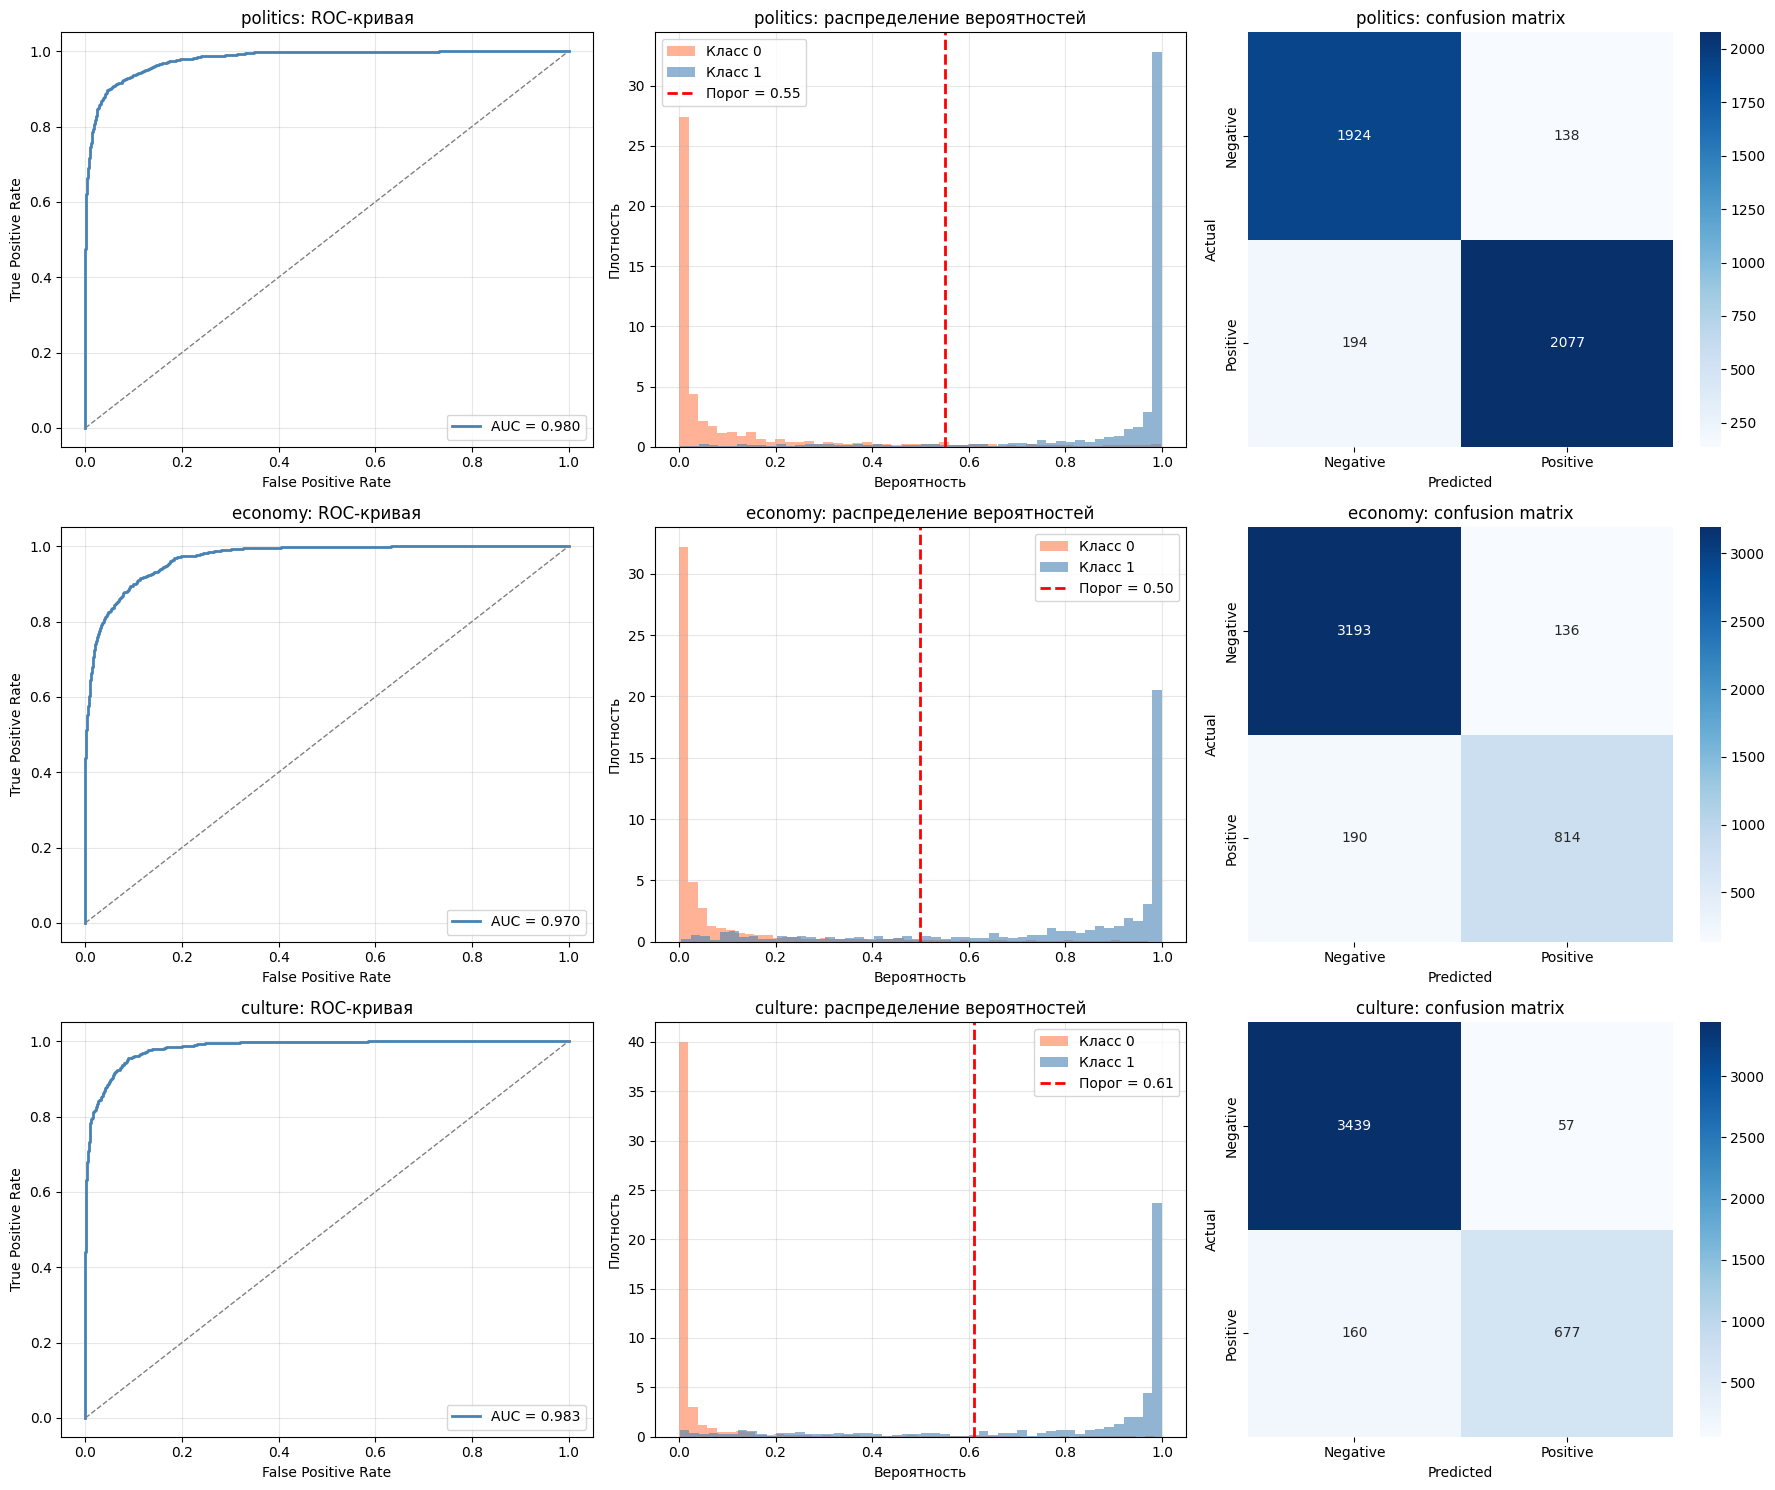


АГРЕГИРОВАННЫЕ МЕТРИКИ
  Macro Precision: 0.9056
  Macro Recall:    0.8447
  Macro F1:        0.8737
  Micro Precision: 0.9151
  Micro Recall:    0.8677
  Micro F1:        0.8908
  Exact Match:     0.8144
  Не классифицировано (на ручную проверку): 1032/4333 (23.8%)

  Оптимальные пороги: {'politics': np.float64(0.5499999999999998), 'economy': np.float64(0.4999999999999998), 'culture': np.float64(0.6099999999999998)}


Время оценки на CPU: 50.8 сек, 4333 записей, 11.7 мс/запись

Итоговая таблица метрик v2:

category  threshold  precision   recall  f1_score  accuracy  auc_roc
    politics       0.55   0.937698 0.914575  0.925992  0.923379 0.980076
     economy       0.50   0.856842 0.810757  0.833163  0.924763 0.970244
     culture       0.61   0.922343 0.808841  0.861871  0.949919 0.983367
   MACRO_AVG        NaN   0.905628 0.844724  0.873675  0.814447      NaN
   MICRO_AVG        NaN   0.915106 0.867704  0.890775  0.814447      NaN
UNCLASSIFIED        NaN        NaN      NaN       NaN       NaN 0.238172

Оптимальные пороги сохранены: {'politics': 0.5499999999999998, 'economy': 0.4999999999999998, 'culture': 
0.6099999999999998}

In [59]:

# ---- Ваш код здесь ----
print("Обученная модель показала хорошие результаты на искусственно созданной выборке, но плохие на реальных данных. " \
"Разметка на первом этапе оказалась шумной. Ручной контроль показал необходимость улучшения разметки. " \
"Либо используем более умную модель для автоматической разметки, либо пытаемся улучшить разметку вручную. " \
"Попробую подобрать пороги для разных категорий в исходной разметке, для этого сохранил ответы модели в процентах уверенности по каждой категории." \
"После этого снова обучим модель с улучшенной разметкой." \
"")

# =====================================================================
# УЛУЧШЕНИЕ РАЗМЕТКИ И ПОДГОТОВКА ДАННЫХ
# =====================================================================
print("=" * 60)
print("УЛУЧШЕНИЕ РАЗМЕТКИ И ПОДГОТОВКА ДАННЫХ")
print("=" * 60)

df_labeled = pd.read_csv("labeled_data_orig.csv")
df_labeled['publication_date'] = pd.to_datetime(df_labeled['publication_date'], utc=True, errors='coerce')
rprint(f"Загружено {len(df_labeled)} записей из labeled_data_orig.csv")

# массив с порогами перевода процента уверенности модели для каждой категории в 0/1 метку, подобранными вручную
label_thresholds: dict[str, int] = {
    'politics': 75,     # для политики порог 75%
    'economy': 60,      # для экономики 60%
    'culture': 60,      # для культуры 60%
    'technology': 50, # если бы была категория технологии
    'sports': 40,     # если бы была категория спорта
}

# пересчитываем бинарные метки по новым порогам из сырого ответа модели (колонка generation)
def extract_label(label_name, gen_text, thresholds):
    """Извлекает числовое значение из ответа LLM и бинаризует по порогу."""
    if not isinstance(gen_text, str):
        return 0
    match = re.search(rf'{label_name}\s*:\s*(\d+)', gen_text)
    if not match:
        return 0
    value = int(match.group(1))
    threshold = thresholds.get(label_name, 50)
    return 1 if value >= threshold else 0

# показываем старые метки для сравнения
rprint("Старая разметка (до пересчёта):")
for col in label_thresholds:
    if col in df_labeled.columns:
        rprint(f"  {col}: {int(df_labeled[col].sum())} положительных из {len(df_labeled)}")

# применяем новые пороги к каждой строке
for col in label_thresholds:
    df_labeled[col] = df_labeled['generation'].apply(
        lambda gen: extract_label(col, gen, label_thresholds)
    )

rprint("\nНовая разметка (после пересчёта):")
for col in label_thresholds:
    rprint(f"  {col}: {int(df_labeled[col].sum())} положительных из {len(df_labeled)}  (порог {label_thresholds[col]}%)")

# сохраняем переразмеченный датасет
df_labeled.to_csv("labeled_data.csv", index=False)
rprint("\nСохранено в labeled_data.csv")


# LABEL_COLS = ['politics', 'economy', 'culture', 'technology', 'sports']
LABEL_COLS = ['politics', 'economy', 'culture']

print("\nЗапускаем EDA и разделение на трейн-тест...")
train_df, test_df = eda_multilabel(df_labeled)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_BERT)

# ОТКАЗ ПОКА для обучения берём только записи с хотя бы одной меткой
#train_mask = train_df[LABEL_COLS].sum(axis=1) > 0
#train_filtered = train_df[train_mask].reset_index(drop=True)
train_filtered = train_df   # для эксперимента с нефильтрованной разметкой
print(f"  Train: {len(train_filtered)} записей (из {len(train_df)}, исключены без меток: {len(train_df) - len(train_filtered)})")
print(f"  Val:   {len(test_df)} записей (все, включая без меток)")

VAL_FILTER = False  # тоже для эксперимента с нефильтрованной валидацией
val_filtered = test_df if not VAL_FILTER else test_df[test_df[LABEL_COLS].sum(axis=1) > 0].reset_index(drop=True)
if VAL_FILTER:
    print(f"  Val (после фильтрации): {len(val_filtered)} записей")

train_dataset2 = NewsDataset(train_filtered, tokenizer, LABEL_COLS)
val_dataset2 = NewsDataset(val_filtered, tokenizer, LABEL_COLS)

train_loader2 = DataLoader(train_dataset2, batch_size=BATCH_SIZE, shuffle=True)
val_loader2 = DataLoader(val_dataset2, batch_size=BATCH_SIZE, shuffle=False)


# =====================================================================
# ОБУЧЕНИЕ (повторное, с переразмеченными данными)
# =====================================================================
print("\n" + "=" * 60)
print("ИНИЦИАЛИЗАЦИЯ МОДЕЛИ (v2)")
print("=" * 60)

model2 = MultiLabelNewsClassifier(MODEL_NAME_BERT, NUM_LABELS).to(DEVICE)
criterion2 = nn.BCEWithLogitsLoss()

total_params = sum(p.numel() for p in model2.parameters())
head_params = sum(p.numel() for p in model2.heads.parameters())
print(f"  Энкодер: {MODEL_NAME_BERT}")
print(f"  Всего параметров: {total_params:,}")
print(f"  Параметров в головах: {head_params:,}")
print(f"  Категории: {LABEL_COLS}")

# ── Фаза 1: прогрев голов (энкодер заморожен) ───────────────────
print("\n" + "=" * 60)
print("ФАЗА 1: ПРОГРЕВ ГОЛОВ (энкодер заморожен)")
print("=" * 60)

model2.freeze_encoder()
optimizer_warmup2 = torch.optim.AdamW(model2.heads.parameters(), lr=WARMUP_LR, weight_decay=WEIGHT_DECAY)

for epoch in range(1, WARMUP_EPOCHS + 1):
    print(f"\n  Эпоха {epoch}/{WARMUP_EPOCHS}")
    train_loss = train_epoch(model2, train_loader2, optimizer_warmup2, criterion2, DEVICE)
    val_loss, metrics = evaluate(model2, val_loader2, criterion2, DEVICE, LABEL_COLS)
    print(f"  Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}")
    print_metrics(metrics, LABEL_COLS)

# ── Фаза 2: дообучение всей модели ──────────────────────────────
print("\n" + "=" * 60)
print("ФАЗА 2: ДООБУЧЕНИЕ ВСЕЙ МОДЕЛИ")
print("=" * 60)

model2.unfreeze_encoder()

optimizer_finetune2 = torch.optim.AdamW([
    {'params': model2.encoder.parameters(), 'lr': FINETUNE_LR_ENCODER, 'weight_decay': WEIGHT_DECAY},
    {'params': model2.heads.parameters(),   'lr': FINETUNE_LR_HEADS,   'weight_decay': WEIGHT_DECAY},
])

scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_finetune2, T_max=FINETUNE_EPOCHS, eta_min=1e-7
)

best_val_loss2 = float('inf')
patience_counter2 = 0

for epoch in range(1, FINETUNE_EPOCHS + 1):
    current_lr_enc = optimizer_finetune2.param_groups[0]['lr']
    current_lr_head = optimizer_finetune2.param_groups[1]['lr']
    print(f"\n  Эпоха {epoch}/{FINETUNE_EPOCHS}  (lr encoder={current_lr_enc:.2e}, heads={current_lr_head:.2e})")

    train_loss = train_epoch(model2, train_loader2, optimizer_finetune2, criterion2, DEVICE)
    val_loss, metrics = evaluate(model2, val_loader2, criterion2, DEVICE, LABEL_COLS)
    scheduler2.step()

    print(f"  Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}")
    print_metrics(metrics, LABEL_COLS)

    if val_loss < best_val_loss2:
        best_val_loss2 = val_loss
        patience_counter2 = 0
        torch.save(model2.state_dict(), "best_model_v2.pt")
        print(f"  -> Лучшая модель сохранена (val_loss={val_loss:.4f})")
    else:
        patience_counter2 += 1
        print(f"  -> Val loss не улучшился ({patience_counter2}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter2 >= EARLY_STOPPING_PATIENCE:
            print(f"  -> Early stopping: val loss не улучшался {EARLY_STOPPING_PATIENCE} эпох подряд")
            break

print(f"\n  Лучший val loss: {best_val_loss2:.4f}")

# ── Сохранение модели v2 ─────────────────────────────────────────
print("\n" + "=" * 60)
print("СОХРАНЕНИЕ МОДЕЛИ v2")
print("=" * 60)

model2.load_state_dict(torch.load("best_model_v2.pt", map_location=DEVICE))
torch.save(model2.state_dict(), "final_model_v2.pt")
tokenizer.save_pretrained("final_tokenizer_v2")

model_config_v2 = {
    'encoder_name': MODEL_NAME_BERT,
    'label_cols': LABEL_COLS,
    'dropout_rate': DROPOUT_RATE,
    'max_seq_len': MAX_SEQ_LEN,
    'label_thresholds': label_thresholds,
    'optimal_thresholds': {},
}
joblib.dump(model_config_v2, "model_config_v2.joblib")
rprint("Сохранено: final_model_v2.pt, final_tokenizer_v2/, model_config_v2.joblib")

# =====================================================================
# ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ
# =====================================================================
print("\n" + "=" * 60)
print("ОЦЕНКА МОДЕЛИ v2 НА ТЕСТОВОЙ ВЫБОРКЕ (CPU)")
print("=" * 60)

eval_device2 = torch.device('cpu')
eval_model2 = MultiLabelNewsClassifier(MODEL_NAME_BERT, NUM_LABELS, DROPOUT_RATE)
eval_model2.load_state_dict(torch.load("final_model_v2.pt", map_location=eval_device2))
eval_model2.to(eval_device2)
eval_model2.eval()
rprint(f"Модель v2 загружена из файла на {eval_device2}")

# для оценки используем полную тестовую выборку (включая записи без меток)
test_dataset_eval2 = NewsDataset(test_df, tokenizer, LABEL_COLS)
test_loader_eval2 = DataLoader(test_dataset_eval2, batch_size=BATCH_SIZE, shuffle=False)

t_start2 = time.time()

metrics_df2 = evaluate_heads_with_plots_and_roc(
    model=eval_model2,
    dataloader=test_loader_eval2,
    device=eval_device2,
    label_cols=LABEL_COLS,
    optimize_threshold=True,
    verbose=True,
    save_path="eval_results_v2",
)

t_end2 = time.time()
elapsed2 = t_end2 - t_start2
n_samples2 = len(test_df)
rprint(f"\nВремя оценки на CPU: {elapsed2:.1f} сек, {n_samples2} записей, {elapsed2/n_samples2*1000:.1f} мс/запись")

rprint("\nИтоговая таблица метрик v2:")
rprint(metrics_df2.to_string(index=False))

# сохраняем оптимальные пороги в конфиг
per_class2 = metrics_df2[metrics_df2['category'].isin(LABEL_COLS)]
optimal_thresholds2 = dict(zip(per_class2['category'], per_class2['threshold']))
model_config_v2['optimal_thresholds'] = optimal_thresholds2
joblib.dump(model_config_v2, "model_config_v2.joblib")
rprint(f"Оптимальные пороги сохранены: {optimal_thresholds2}")


# ---- Конец кода ----

### Результаты улучшений
Обучение и валидация проводились по всему корпусу данных, без фильтрации. Это дало повышение Precision и F1, что хорошо. Не классифицированные данные составили 24%, что примерно соответствует исходным даннным (там было 19%).


## 11. Расширение категорий (10 баллов)

Как это часто бывает, к вам пришел бизнес и сказал: "мы передумали".

Всё тщательно обсудив на встрече, главный продакт-менеджер заявил, что новостное агентство нуждается в другом наборе категорий, а именно: нужно выделить новые категории, "технологии" и "спорт", а три старые в целом могут оставаться на месте (правда никто не знает, надолго ли).

Итого, **новый список:** `["политика","экономика","технологии","спорт","культура"]`

Реализуйте это изменение и выведите новые метрики по всем категориям (старым и новым), но перед этим посмотрите на архитектуру своего решения и ответьте на вопрос -- насколько легко и удобно будет а) добавлять новые категории в вашем ML б) перекатывать сервис?

Масштабируем на новые классы
Необходимо доразметить датасет с новыми данными (спорт и технологии), что уже было сделано. После этого нужно повторить процесс обучения, но уже с 5 категориями. Поскольку модель уже обучена на 3 категориях, можно дообучить её на 5 категориях, заморозив энкодер и головы для старых категорий, и добавив 2 новые головы для новых категорий. Либо можно обучить модель с нуля на всех 5 категориях, что может дать лучший результат, но займет больше времени. После обучения нужно будет провести оценку по тем же метрикам, построить графики и сравнить с предыдущей версией модели, чтобы понять влияние добавления новых категорий на качество классификации.По идее, при обучении новых двух голов, старые метрики по первым трем категоримям не изменятся.

ДООБУЧЕНИЕ ДВУХ НОВЫХ ГОЛОВ (технологии и спорт)
  Энкодер v2 сохранён в encoder_v2/
  Загружены головы v2. Новые (случайные) параметры: ['heads.3.weight', 'heads.3.bias', 'heads.4.weight', 'heads.4.bias']
  Обучаемых параметр

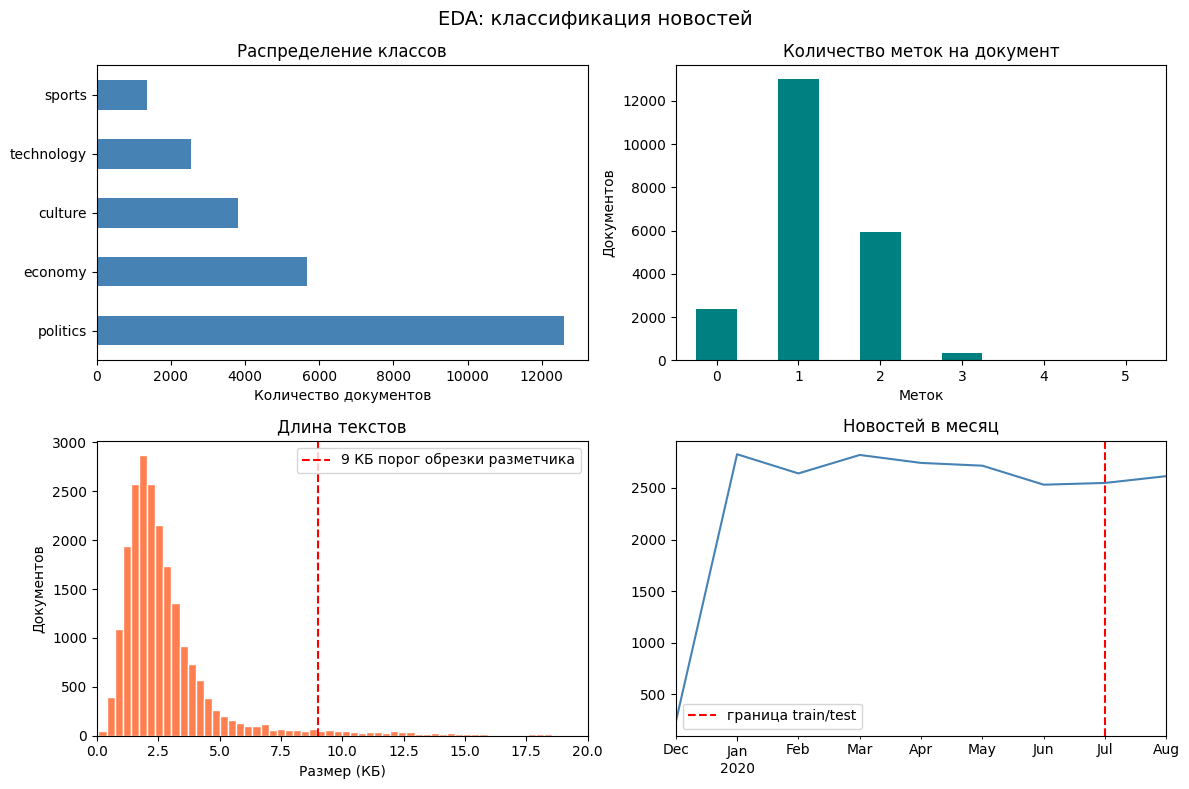


  График сохранён: eda_report.png

ОБУЧЕНИЕ НОВЫХ ГОЛОВ

  Эпоха 1/10


  Train loss: 0.2033  |  Val loss: 0.1692
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9263     0.9243     0.9253     0.9218
  economy             0.8568     0.8108     0.8332     0.9248
  culture             0.8892     0.8339     0.8607     0.9478
  technology          0.9495     0.4816     0.6391     0.9215
  sports              1.0000     0.3223     0.4875     0.9573
  -> Лучшая модель сохранена (val_loss=0.1692)

  Эпоха 2/10


  Train loss: 0.1616  |  Val loss: 0.1582
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9263     0.9243     0.9253     0.9218
  economy             0.8568     0.8108     0.8332     0.9248
  culture             0.8892     0.8339     0.8607     0.9478
  technology          0.9007     0.5952     0.7168     0.9321
  sports              0.9558     0.3956     0.5596     0.9608
  -> Лучшая модель сохранена (val_loss=0.1582)

  Эпоха 3/10


  Train loss: 0.1578  |  Val loss: 0.1547
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9263     0.9243     0.9253     0.9218
  economy             0.8568     0.8108     0.8332     0.9248
  culture             0.8892     0.8339     0.8607     0.9478
  technology          0.8901     0.6352     0.7414     0.9361
  sports              0.9032     0.4103     0.5642     0.9601
  -> Лучшая модель сохранена (val_loss=0.1547)

  Эпоха 4/10


  Train loss: 0.1558  |  Val loss: 0.1535
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9263     0.9243     0.9253     0.9218
  economy             0.8568     0.8108     0.8332     0.9248
  culture             0.8892     0.8339     0.8607     0.9478
  technology          0.8909     0.6272     0.7362     0.9351
  sports              0.8846     0.4212     0.5707     0.9601
  -> Лучшая модель сохранена (val_loss=0.1535)

  Эпоха 5/10


...

  Train loss: 0.1523  |  Val loss: 0.1499
  Категория        Precision     Recall         F1   Accuracy
  politics            0.9263     0.9243     0.9253     0.9218
  economy             0.8568     0.8108     0.8332     0.9248
  culture             0.8892     0.8339     0.8607     0.9478
  technology          0.8765     0.6928     0.7739     0.9416
  sports              0.8194     0.4652     0.5935     0.9598
  -> Лучшая модель сохранена (val_loss=0.1499)

  Лучший val loss: 0.1499

СОХРАНЕНИЕ МОДЕЛИ v3 (5 категорий)


Сохранено: final_model_v3.pt, final_tokenizer_v3/, model_config_v3.joblib


ОЦЕНКА МОДЕЛИ v3 НА ТЕСТОВОЙ ВЫБОРКЕ (CPU)


Модель v3 загружена из файла на cpu


Категория: politics  (порог=0.55)
  Precision: 0.9377
  Recall:    0.9146
  F1:        0.9260
  Accuracy:  0.9234
  ROC AUC:   0.9801

Категория: economy  (порог=0.50)
  Precision: 0.8568
  Recall:    0.8108
  F1:        0.8332
  Accuracy:  0.9248
  ROC AUC:   0.9702

Категория: culture  (порог=0.61)
  Precision: 0.9223
  Recall:    0.8088
  F1:        0.8619
  Accuracy:  0.9499
  ROC AUC:   0.9834

Категория: technology  (порог=0.37)
  Precision: 0.8392
  Recall:    0.7680
  F1:        0.8020
  Accuracy:  0.9453
  ROC AUC:   0.9690

Категория: sports  (порог=0.24)
  Precision: 0.6119
  Recall:    0.6410
  F1:        0.6261
  Accuracy:  0.9518
  ROC AUC:   0.9383

  Графики сохранены: eval_results_v3/evaluation_plots.png


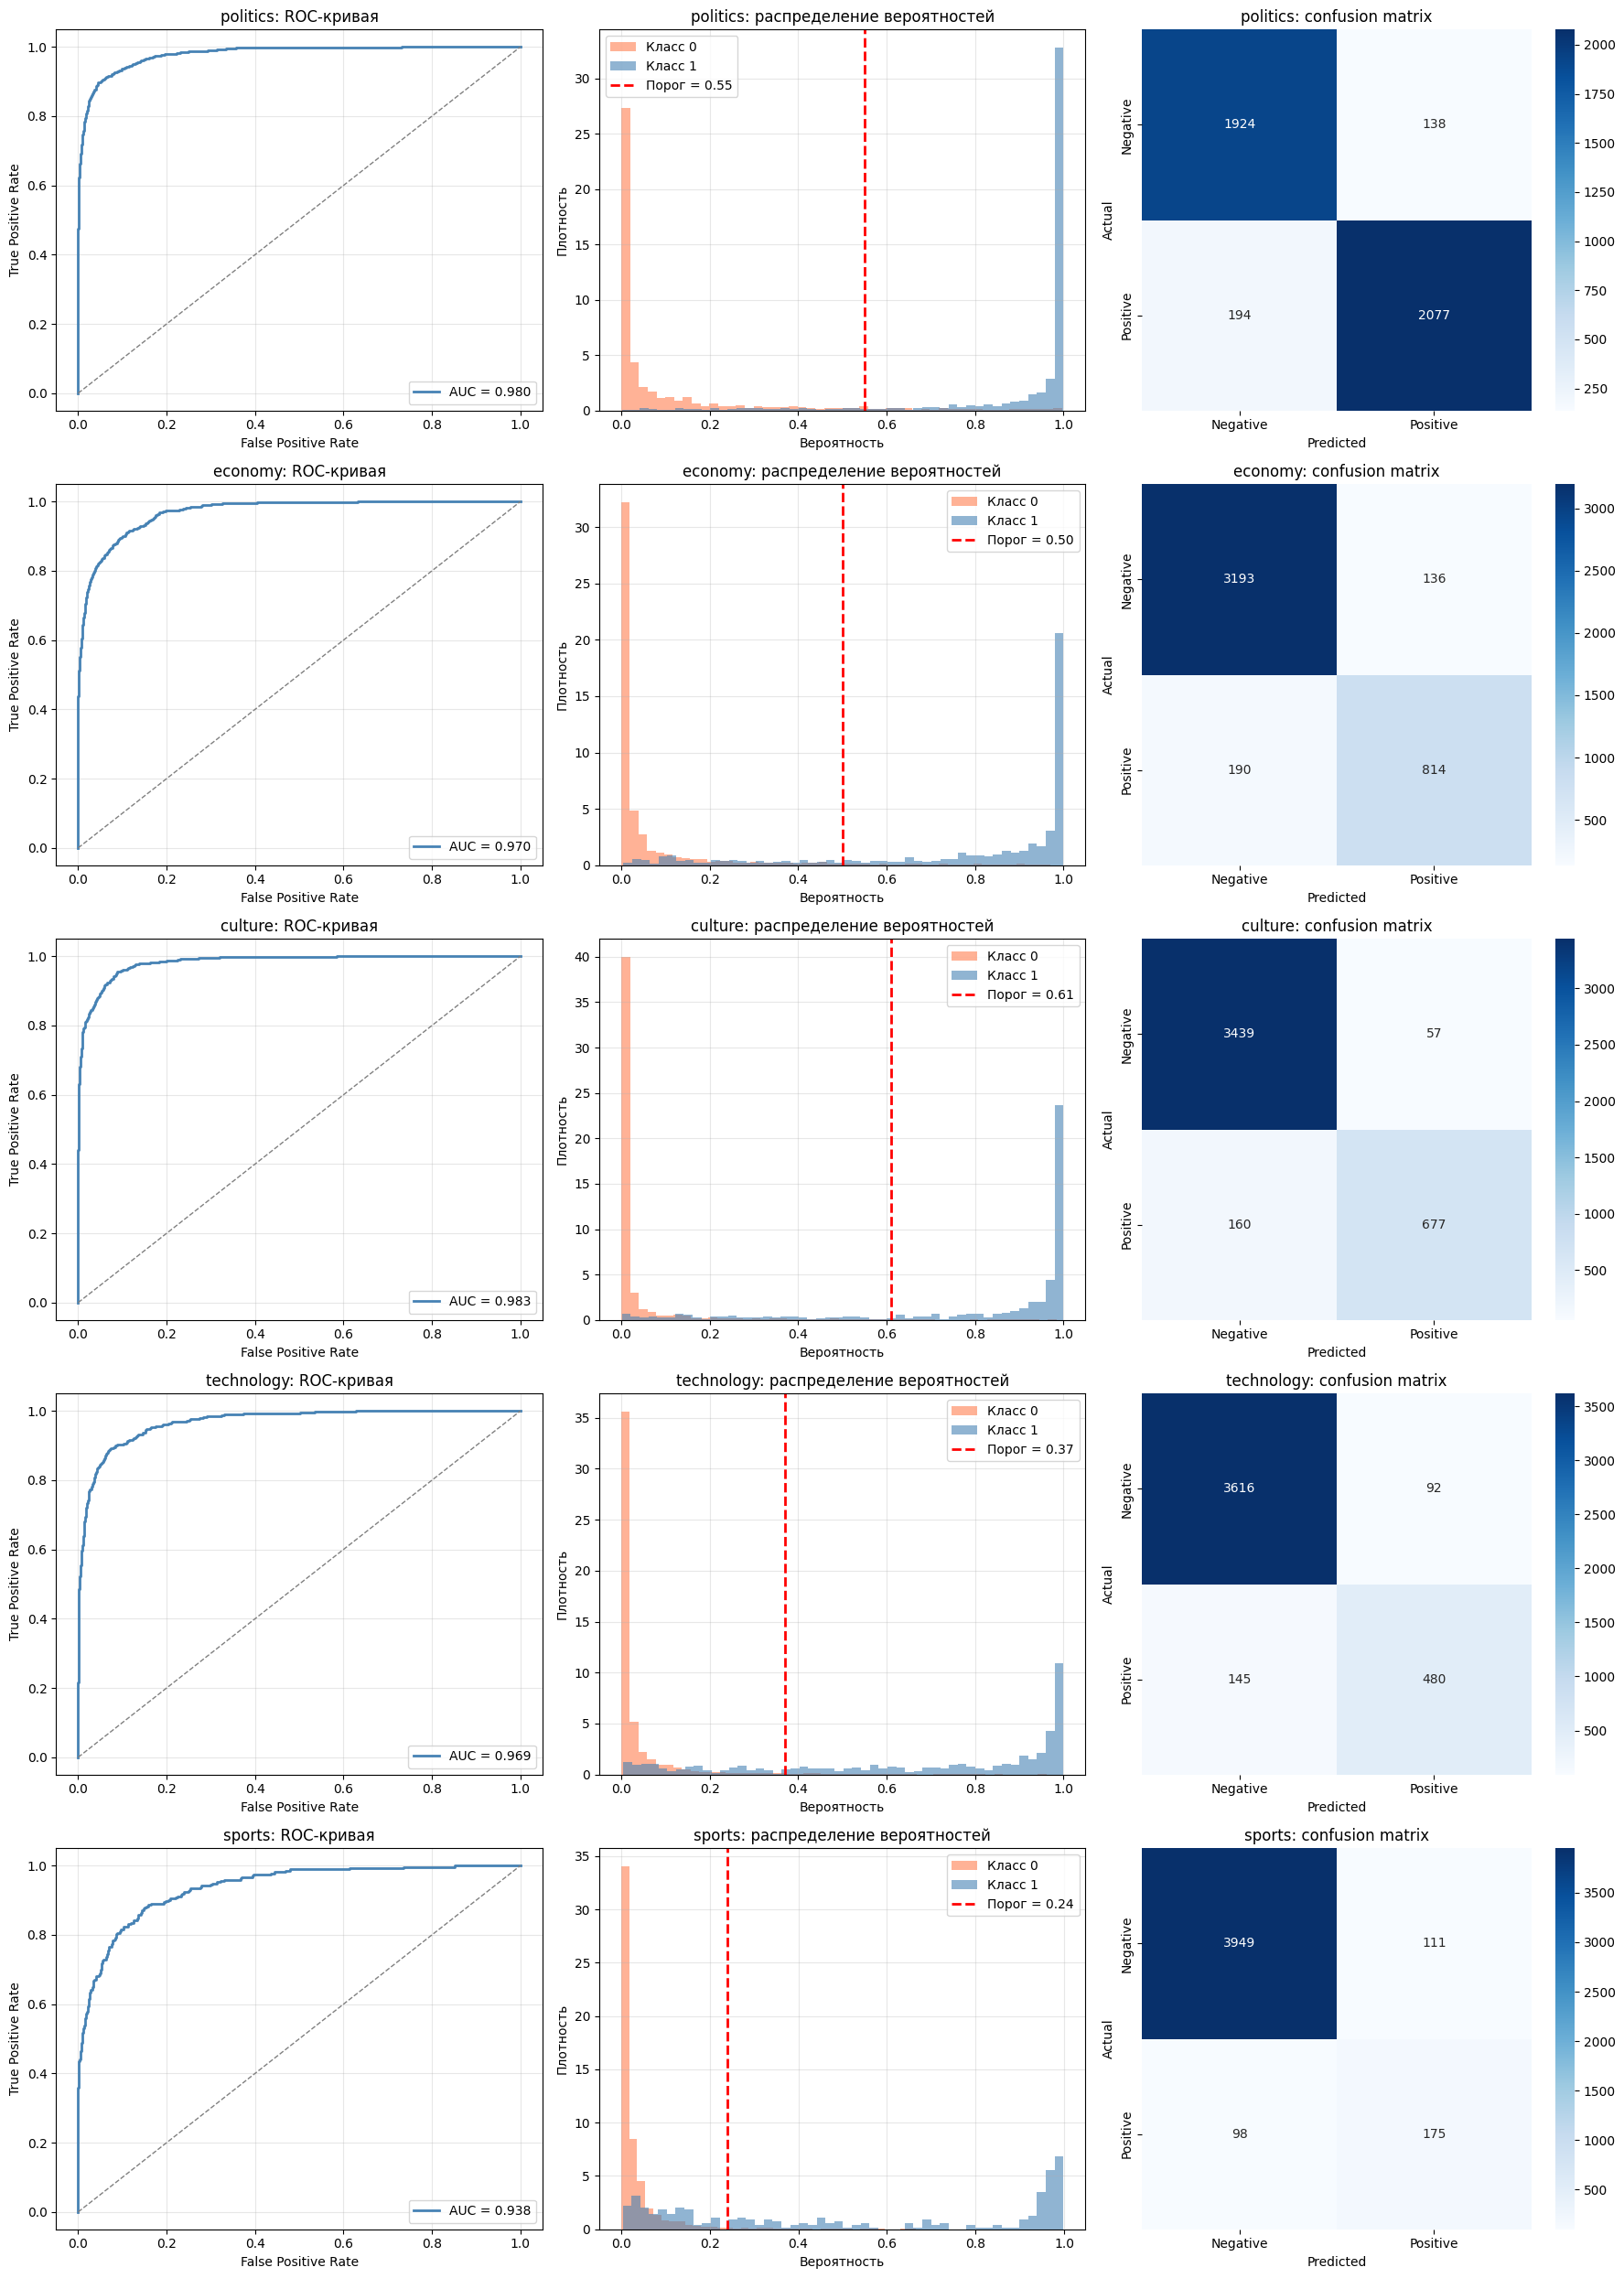


АГРЕГИРОВАННЫЕ МЕТРИКИ
  Macro Precision: 0.8336
  Macro Recall:    0.7886
  Macro F1:        0.8098
  Micro Precision: 0.8877
  Micro Recall:    0.8429
  Micro F1:        0.8647
  Exact Match:     0.7348
  Не классифицировано (на ручную проверку): 598/4333 (13.8%)

  Оптимальные пороги: {'politics': np.float64(0.5499999999999998), 'economy': np.float64(0.4999999999999998), 'culture': np.float64(0.6099999999999998), 'technology': np.float64(0.3699999999999999), 'sports': np.float64(0.23999999999999994)}


Время оценки на CPU: 132.8 сек, 4333 записей, 30.6 мс/запись

Итоговая таблица метрик v3:

category  threshold  precision   recall  f1_score  accuracy  auc_roc
    politics       0.55   0.937698 0.914575  0.925992  0.923379 0.980076
     economy       0.50   0.856842 0.810757  0.833163  0.924763 0.970244
     culture       0.61   0.922343 0.808841  0.861871  0.949919 0.983367
  technology       0.37   0.839161 0.768000  0.802005  0.945303 0.968964
      sports       0.24   0.611888 0.641026  0.626118  0.951766 0.938319
   MACRO_AVG        NaN   0.833586 0.788640  0.809830  0.734826      NaN
   MICRO_AVG        NaN   0.887744 0.842914  0.864749  0.734826      NaN
UNCLASSIFIED        NaN        NaN      NaN       NaN       NaN 0.138011

Оптимальные пороги сохранены: {'politics': 0.5499999999999998, 'economy': 0.4999999999999998, 'culture': 
0.6099999999999998, 'technology': 0.3699999999999999, 'sports': 0.23999999999999994}


СРАВНЕНИЕ: старые категории v2 vs v3
  politics         F1 v2=0.9260  F1 v3=0.9260  delta=+0.0000  [OK]
  economy          F1 v2=0.8332  F1 v3=0.8332  delta=+0.0000  [OK]
  culture          F1 v2=0.8619  F1 v3=0.8619  delta=+0.0000  [OK]


In [60]:

# ---- Ваш код здесь ----
print("Масштабируем на новые классы")

print("Необходимо доразметить датасет с новыми данными (спорт и технологии), что уже было сделано." \
" После этого нужно повторить процесс обучения, но уже с 5 категориями. " \
"Поскольку модель уже обучена на 3 категориях, можно дообучить её на 5 категориях, " \
"заморозив энкодер и головы для старых категорий, и добавив 2 новые головы для новых категорий. " \
"Либо можно обучить модель с нуля на всех 5 категориях, что может дать лучший результат, но займет больше времени. " \
"После обучения нужно будет провести оценку по тем же метрикам, построить графики и сравнить с предыдущей версией модели, " \
"чтобы понять влияние добавления новых категорий на качество классификации." \
"По идее, при обучении новых двух голов, старые метрики по первым трем категоримям не изменятся.")

print("\n" + "=" * 60)
print("ДООБУЧЕНИЕ ДВУХ НОВЫХ ГОЛОВ (технологии и спорт)")
print("=" * 60)

NEW_LABELS = ['technology', 'sports']
LABEL_COLS_V3 = ['politics', 'economy', 'culture', 'technology', 'sports']
NUM_LABELS_V3 = len(LABEL_COLS_V3)

# ── 1. Сохраняем дообученный энкодер v2 как pretrained ───────────
# чтобы не грузить исходный с HF и потом затирать весами
model2.encoder.save_pretrained("encoder_v2")
print("  Энкодер v2 сохранён в encoder_v2/")

# ── 2. Создаём модель с 5 головами на базе дообученного энкодера ──
model3 = MultiLabelNewsClassifier("encoder_v2", NUM_LABELS_V3).to(DEVICE)

# загружаем веса голов v2 (3 головы) с strict=False —
# encoder уже правильный, heads.0-2 подхватятся, heads.3-4 останутся случайными
state_dict_v2 = torch.load("final_model_v2.pt", map_location=DEVICE)
# оставляем только веса голов (энкодер уже загружен правильный)
head_weights = {k: v for k, v in state_dict_v2.items() if k.startswith('heads.')}
missing, unexpected = model3.load_state_dict(head_weights, strict=False)
print(f"  Загружены головы v2. Новые (случайные) параметры: {[k for k in missing if 'heads' in k]}")

# ── 2. Замораживаем энкодер и старые головы (0, 1, 2) ────────────
model3.freeze_encoder()
for i in range(3):  # politics=0, economy=1, culture=2
    for param in model3.heads[i].parameters():
        param.requires_grad = False

# проверяем: обучаемые только новые головы
trainable = sum(p.numel() for p in model3.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model3.parameters() if not p.requires_grad)
print(f"  Обучаемых параметров: {trainable:,} (новые головы)")
print(f"  Замороженных параметров: {frozen:,} (энкодер + старые головы)")

# ── 3. Подготовка данных с 5 категориями ─────────────────────────
# переразметка technology и sports уже сделана ранее в df_labeled
# нужно заново разделить на train/test с новыми колонками
print("\nПодготовка данных с 5 категориями...")
train_df3, test_df3 = eda_multilabel(df_labeled, label_cols=LABEL_COLS_V3)

train_dataset3 = NewsDataset(train_df3, tokenizer, LABEL_COLS_V3)
val_dataset3 = NewsDataset(test_df3, tokenizer, LABEL_COLS_V3)

train_loader3 = DataLoader(train_dataset3, batch_size=BATCH_SIZE, shuffle=True)
val_loader3 = DataLoader(val_dataset3, batch_size=BATCH_SIZE, shuffle=False)

# ── 4. Обучение только новых голов ───────────────────────────────
# собираем параметры только новых голов (indices 3 и 4)
new_head_params = []
for i in range(3, NUM_LABELS_V3):
    new_head_params.extend(model3.heads[i].parameters())

criterion3 = nn.BCEWithLogitsLoss()
optimizer3 = torch.optim.AdamW(new_head_params, lr=WARMUP_LR, weight_decay=WEIGHT_DECAY)

NEW_HEAD_EPOCHS = 10

print("\n" + "=" * 60)
print("ОБУЧЕНИЕ НОВЫХ ГОЛОВ")
print("=" * 60)

best_val_loss3 = float('inf')
patience_counter3 = 0

for epoch in range(1, NEW_HEAD_EPOCHS + 1):
    print(f"\n  Эпоха {epoch}/{NEW_HEAD_EPOCHS}")

    train_loss = train_epoch(model3, train_loader3, optimizer3, criterion3, DEVICE)
    val_loss, metrics = evaluate(model3, val_loader3, criterion3, DEVICE, LABEL_COLS_V3)

    print(f"  Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}")
    print_metrics(metrics, LABEL_COLS_V3)

    if val_loss < best_val_loss3:
        best_val_loss3 = val_loss
        patience_counter3 = 0
        torch.save(model3.state_dict(), "best_model_v3.pt")
        print(f"  -> Лучшая модель сохранена (val_loss={val_loss:.4f})")
    else:
        patience_counter3 += 1
        print(f"  -> Val loss не улучшился ({patience_counter3}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter3 >= EARLY_STOPPING_PATIENCE:
            print(f"  -> Early stopping")
            break

print(f"\n  Лучший val loss: {best_val_loss3:.4f}")

# ── 5. Сохранение модели v3 ──────────────────────────────────────
print("\n" + "=" * 60)
print("СОХРАНЕНИЕ МОДЕЛИ v3 (5 категорий)")
print("=" * 60)

model3.load_state_dict(torch.load("best_model_v3.pt", map_location=DEVICE))
torch.save(model3.state_dict(), "final_model_v3.pt")
tokenizer.save_pretrained("final_tokenizer_v3")

model_config_v3 = {
    'encoder_name': MODEL_NAME_BERT,
    'label_cols': LABEL_COLS_V3,
    'dropout_rate': DROPOUT_RATE,
    'max_seq_len': MAX_SEQ_LEN,
    'label_thresholds': label_thresholds,
    'optimal_thresholds': {},
}
joblib.dump(model_config_v3, "model_config_v3.joblib")
rprint("Сохранено: final_model_v3.pt, final_tokenizer_v3/, model_config_v3.joblib")

# ── 6. Оценка v3 на тестовой выборке (CPU) ───────────────────────
print("\n" + "=" * 60)
print("ОЦЕНКА МОДЕЛИ v3 НА ТЕСТОВОЙ ВЫБОРКЕ (CPU)")
print("=" * 60)

eval_device3 = torch.device('cpu')
eval_model3 = MultiLabelNewsClassifier(MODEL_NAME_BERT, NUM_LABELS_V3, DROPOUT_RATE)
eval_model3.load_state_dict(torch.load("final_model_v3.pt", map_location=eval_device3))
eval_model3.to(eval_device3)
eval_model3.eval()
rprint(f"Модель v3 загружена из файла на {eval_device3}")

test_dataset_eval3 = NewsDataset(test_df3, tokenizer, LABEL_COLS_V3)
test_loader_eval3 = DataLoader(test_dataset_eval3, batch_size=BATCH_SIZE, shuffle=False)

t_start3 = time.time()

metrics_df3 = evaluate_heads_with_plots_and_roc(
    model=eval_model3,
    dataloader=test_loader_eval3,
    device=eval_device3,
    label_cols=LABEL_COLS_V3,
    optimize_threshold=True,
    verbose=True,
    save_path="eval_results_v3",
)

t_end3 = time.time()
elapsed3 = t_end3 - t_start3
n_samples3 = len(test_df3)
rprint(f"\nВремя оценки на CPU: {elapsed3:.1f} сек, {n_samples3} записей, {elapsed3/n_samples3*1000:.1f} мс/запись")

rprint("\nИтоговая таблица метрик v3:")
rprint(metrics_df3.to_string(index=False))

# сохраняем оптимальные пороги
per_class3 = metrics_df3[metrics_df3['category'].isin(LABEL_COLS_V3)]
optimal_thresholds3 = dict(zip(per_class3['category'], per_class3['threshold']))
model_config_v3['optimal_thresholds'] = optimal_thresholds3
joblib.dump(model_config_v3, "model_config_v3.joblib")
rprint(f"Оптимальные пороги сохранены: {optimal_thresholds3}")

# ── 7. Сравнение: старые головы не деградировали? ────────────────
print("\n" + "=" * 60)
print("СРАВНЕНИЕ: старые категории v2 vs v3")
print("=" * 60)
OLD_LABELS = ['politics', 'economy', 'culture']
for label in OLD_LABELS:
    m2 = metrics_df2[metrics_df2['category'] == label].iloc[0]
    m3 = metrics_df3[metrics_df3['category'] == label].iloc[0]
    delta_f1 = m3['f1_score'] - m2['f1_score']
    status = "OK" if abs(delta_f1) < 0.01 else ("+" if delta_f1 > 0 else "DEGRADED")
    print(f"  {label:<15}  F1 v2={m2['f1_score']:.4f}  F1 v3={m3['f1_score']:.4f}  delta={delta_f1:+.4f}  [{status}]")

# ---- Конец кода ----

## Промежуточный итог

Можно отметить, что неклассифицированные данные изначально составляют 11%, и в выводе обученной модели составляют 13,8%, что достаточно близко. Тут надо думать скорее о расширении списка категорий. Exact match 73% при пяти категориях не так уж и плохо, учитывая что Спорт тянет всех вниз. Micro Precision и Recall проседают из-за категории Спорт, в которой мало данных и распределение вероятностей сильно сдвинуто в сторону 0 (последний график), модель их очень неуверенно предсказывает.
Давайте быстро посчитаем без спорта:


In [61]:

# =====================================================================
# Micro Precision без категории Sports
# =====================================================================
print("\n" + "=" * 60)
print("MICRO PRECISION БЕЗ КАТЕГОРИИ SPORTS")
print("=" * 60)

# получаем вероятности и метки из уже загруженной модели v3
all_probs3, all_labels3 = get_all_predictions(eval_model3, test_loader_eval3, eval_device3)

# бинаризуем по оптимальным порогам v3
all_preds3 = np.zeros_like(all_probs3, dtype=int)
for i, cat in enumerate(LABEL_COLS_V3):
    all_preds3[:, i] = (all_probs3[:, i] >= optimal_thresholds3[cat]).astype(int)

# индексы категорий без sports
no_sports = [i for i, c in enumerate(LABEL_COLS_V3) if c != 'sports']
labels_subset = LABEL_COLS_V3.copy()
labels_subset.remove('sports')

micro_p_no_sports, micro_r_no_sports, micro_f1_no_sports, _ = precision_recall_fscore_support(
    all_labels3[:, no_sports], all_preds3[:, no_sports], average='micro', zero_division=0
)

print(f"  Категории: {labels_subset}")
print(f"  Micro Precision: {micro_p_no_sports:.4f} ({micro_p_no_sports*100:.1f}%)")
print(f"  Micro Recall:    {micro_r_no_sports:.4f} ({micro_r_no_sports*100:.1f}%)")
print(f"  Micro F1:        {micro_f1_no_sports:.4f} ({micro_f1_no_sports*100:.1f}%)")



MICRO PRECISION БЕЗ КАТЕГОРИИ SPORTS


  Категории: ['politics', 'economy', 'culture', 'technology']
  Micro Precision: 0.9054 (90.5%)
  Micro Recall:    0.8545 (85.5%)
  Micro F1:        0.8792 (87.9%)


## Совсем последнее

Без спорта попадаем в бизнес-метрики. Надо отдавать в продакшн со словами "а спорт надо лучше освещать".

| Метрика            | Требование | v1 (3 кат.) | v2 (3 кат.) | v3 (5 кат.) | v3 без sports |
|--------------------|------------|-------------|-------------|-------------|---------------|
| Ручная проверка    | < 15%      | 17.3% ❌    | 23.8% ❌    | 13.8% ✅    | 13.8% ✅      |
| Micro Precision    | > 90%      | 78.9% ❌    | 91.5% ✅    | 88.8% ❌    | 90.5% ✅      |
| Micro Recall       | > 85%      | 87.0% ✅    | 86.8% ✅    | 84.3% ❌    | 85.5% ✅      |
| Micro F1           | —          | 82.7%       | 89.1%       | 86.5%       | 87.9%         |
| Macro F1           | —          | 76.7%       | 87.4%       | 81.0%       | 85.5%         |

Забавно, что цифры были изначально взяты из головы, и в них как раз получилось уложиться. Это случайность.

Получилось добавить две категории без изменения основной модели и существующих голов, хотя пример Спорта показывает, что (наверное) лучше было всю модель разморозить и слегка подучить, выставив lr низким для существующих весов.

Куда идти дальше: надо разморозить энкодер с целью поднять распознаваемость спорта, и одновременно накраулить больше данных со спортивных сайтов (в датасете спортивных сайтов не было вообще, одна политика). По количеству достаточно донабрать ещё 1-2К примеров спорта, как в остальных категориях. Независимо от этого добавить категории "происшествия" и "здоровье" - туда попадут почти все неклассифицированные данные, и recall вырастет сам.

## Важное замечание

Большая часть кода написана с помощью Claude Code. Однако, я всё переносил в notebook и дорабатывал сам с пониманием процесса. Задание оказалось для меня сложным и объёмным. Лекцию понял гораздо лучше в процессе работы над домашкой.